# Systematic Trading Strategies with Machine Learning  
## Coursework Project – Meta-Labeling for Trading Signal Filtering

---

# 1. Project Overview

The objective of this project is to build a **metamodel** on top of a provided primary trading signal across futures contracts from multiple asset classes.

The primary model generates daily trading signals in \(\{-1,0,+1\}\):
- \(+1\): long signal
- \(-1\): short signal
- \(0\): no position

Our goal is **not** to predict returns directly.  
Instead, we aim to estimate the probability that a given primary signal is worth taking under a triple-barrier labeling framework.

More formally, we seek to model:

\[
P(\text{Trade is profitable} \mid \text{Features})
\]

using machine learning techniques.

---

# 2. Project Pipeline

The project is structured into the following stages:

## Phase 1 — Data Preparation and Exploration
- Load and clean OHLCV data
- Load and align primary signals
- Verify data integrity and temporal consistency
- Explore the characteristics of each asset class

## Phase 2 — Feature Engineering
Construction of predictive features from market data, including:
- Technical indicators
- Volatility and momentum features
- Cross-sectional features
- Latent regime features (HMM/GMM)
- Additional engineered features

## Phase 3 — Triple-Barrier Labeling
Implementation of the triple-barrier method to define supervised learning targets:
- Profit-taking barrier
- Stop-loss barrier
- Maximum holding period

We will justify all parameter choices economically and statistically.

## Phase 4 — Model Development
We will compare several model families:
- Linear models
- Tree-based ensemble methods
- Neural networks

Hyperparameter tuning and robust validation procedures will be applied.

## Phase 5 — Feature Importance Analysis
We will study:
- Individual feature importance
- Cluster-level feature importance
- SHAP/permutation-based interpretability

## Phase 6 — Out-of-Sample Evaluation
Evaluation on a clean out-of-sample period using:
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion matrices
- Comparison against the raw primary signal

## Optional Phase 7 — Strategy Construction
(Optional competition track)

Construction of a position-sizing strategy using metamodel probabilities.

---

# 3. Methodological Principles

Throughout the project, particular attention will be paid to:
- Avoiding look-ahead bias
- Preventing data leakage
- Using time-aware validation procedures
- Ensuring reproducibility
- Maintaining economic interpretability of results

The emphasis of this coursework is placed on:
- methodological rigor,
- feature engineering quality,
- validation protocol,
- and critical analysis of results.

---

# 4. Asset Universe

The project covers futures contracts from three asset classes:

## Equity Index Futures
- ES1S — S&P 500
- NQ1S — Nasdaq 100
- FESX1S — Euro Stoxx 50

## Energy
- CL1S — WTI Crude Oil
- HO1S — Heating Oil
- RB1S — RBOB Gasoline
- NG1S — Natural Gas

## Metals
- GC1S — Gold
- SI1S — Silver
- HG1S — Copper
- PL1S — Platinum

---

# 5. Initial Setup

We begin by importing the required libraries and loading the datasets.

# Phase 1 — Data Preparation and Initial Exploration

In this first phase, we prepare the raw datasets for the meta-labeling pipeline.

We focus initially on the **Energy** asset class:

| Ticker | Commodity |
|---|---|
| CL1S | WTI Crude Oil |
| HO1S | Heating Oil |
| RB1S | RBOB Gasoline |
| NG1S | Natural Gas |

The objectives of this phase are:

1. Load the OHLCV dataset and the primary signals dataset.
2. Standardize dates, instrument names, and column formats.
3. Filter the universe to Energy instruments only.
4. Align market data and primary signals on a common trading calendar.
5. Perform basic data integrity checks:
   - missing values,
   - duplicated rows,
   - date coverage,
   - signal distribution,
   - price and volume sanity checks.
6. Prepare a clean base dataframe that will later be used for feature engineering and triple-barrier labeling.

At this stage, we do **not** create labels yet.  
The purpose is to build a clean, reliable data foundation before moving to feature engineering.

In [103]:
from numpy import lib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import statsmodels.api as sm1
import talib
from hmmlearn.hmm import GaussianHMM
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [104]:
# ============================================================
# Phase 1 — Setup and Data Loading
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Display options
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# ------------------------------------------------------------
# Project configuration
# ------------------------------------------------------------

DATA_DIR = "."  # Change this path if your CSV files are in another folder

OHLCV_FILE = os.path.join(DATA_DIR, "ohlcv_data.csv")
SIGNALS_FILE = os.path.join(DATA_DIR, "primary_signals.csv")

ENERGY_INSTRUMENTS = ["cl1s", "ho1s", "rb1s", "ng1s"]

INSTRUMENT_NAMES = {
    "cl1s": "WTI Crude Oil",
    "ho1s": "Heating Oil",
    "rb1s": "RBOB Gasoline",
    "ng1s": "Natural Gas",
}

print("Energy universe:")
for ticker, name in INSTRUMENT_NAMES.items():
    print(f"- {ticker.upper()}: {name}")

Energy universe:
- CL1S: WTI Crude Oil
- HO1S: Heating Oil
- RB1S: RBOB Gasoline
- NG1S: Natural Gas


In [105]:
# ============================================================
# Load Raw Data
# ============================================================

ohlcv_raw = pd.read_csv(OHLCV_FILE)
signals_raw = pd.read_csv(SIGNALS_FILE)

print("OHLCV shape:", ohlcv_raw.shape)
print("Signals shape:", signals_raw.shape)

display(ohlcv_raw.head())
display(signals_raw.head())

OHLCV shape: (83547, 8)
Signals shape: (645, 12)


,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.8000,22.920,21.7900,22.8900,22868.0,66308.0
1,1990-01-02,gc1s,401.0000,404.600,400.2000,402.1000,20747.0,68855.0
2,1990-01-02,hg1s,1.0470,1.064,1.0430,1.0620,3325.0,19735.0
3,1990-01-02,ho1s,0.7475,0.776,0.7415,0.7739,20280.0,33732.0
4,1990-01-02,pl1s,484.0000,485.000,479.5000,482.2000,4561.0,13256.0


,date,es1s,nq1s,fesx1s,cl1s,ho1s,rb1s,ng1s,gc1s,si1s,hg1s,pl1s
0,2020-01-03,1,1,-1,0,0,1,0,0,1,1,-1
1,2020-01-06,1,-1,1,0,0,1,0,0,1,1,1
2,2020-01-07,1,-1,1,-1,0,-1,0,0,1,1,1
3,2020-01-08,1,1,1,0,0,1,0,0,1,1,1
4,2020-01-09,1,-1,-1,0,0,1,0,0,1,1,1


## 1.1 Initial Data Standardization

We now standardize the two datasets:

- convert dates to `datetime`,
- convert instrument names to lowercase,
- sort observations chronologically,
- filter the OHLCV data and primary signals to the Energy instruments only.

This ensures that both datasets use the same naming convention and can later be merged safely.

In [106]:
# ============================================================
# Standardize Dates and Instrument Names
# ============================================================

ohlcv = ohlcv_raw.copy()
signals = signals_raw.copy()

# Convert date columns
ohlcv["date"] = pd.to_datetime(ohlcv["date"])
signals["date"] = pd.to_datetime(signals["date"])

# Standardize instrument names
ohlcv["instrument"] = ohlcv["instrument"].str.lower()

# Keep only Energy instruments
ohlcv_energy = ohlcv[ohlcv["instrument"].isin(ENERGY_INSTRUMENTS)].copy()

# Keep date + Energy signal columns
signals_energy = signals[["date"] + ENERGY_INSTRUMENTS].copy()

# Sort
ohlcv_energy = ohlcv_energy.sort_values(["instrument", "date"]).reset_index(drop=True)
signals_energy = signals_energy.sort_values("date").reset_index(drop=True)

print("Energy OHLCV shape:", ohlcv_energy.shape)
print("Energy signals shape:", signals_energy.shape)

display(ohlcv_energy.head())
display(signals_energy.head())

Energy OHLCV shape: (32614, 8)
Energy signals shape: (645, 5)


,date,instrument,open,high,low,close,volume,open_interest
0,1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0
1,1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0
2,1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0
3,1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0
4,1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0


,date,cl1s,ho1s,rb1s,ng1s
0,2020-01-03,0,0,1,0
1,2020-01-06,0,0,1,0
2,2020-01-07,-1,0,-1,0
3,2020-01-08,0,0,1,0
4,2020-01-09,0,0,1,0


## 1.2 Data Integrity Checks

Before creating features or labels, we first verify the quality of the raw Energy datasets.

We check:
- date coverage by instrument,
- duplicated observations,
- missing values,
- OHLCV consistency,
- and primary signal distributions.

These checks are important because any data issue at this stage could later create misleading labels, feature leakage, or incorrect model evaluation.

In [107]:
# ============================================================
# Basic Data Integrity Checks
# ============================================================

print("OHLCV date range by instrument:")
display(
    ohlcv_energy
    .groupby("instrument")["date"]
    .agg(["min", "max", "count"])
)

print("\nSignals date range:")
display(
    signals_energy["date"].agg(["min", "max", "count"])
)

print("\nDuplicate OHLCV rows by (date, instrument):")
n_dup_ohlcv = ohlcv_energy.duplicated(subset=["date", "instrument"]).sum()
print(n_dup_ohlcv)

print("\nDuplicate signal dates:")
n_dup_signals = signals_energy.duplicated(subset=["date"]).sum()
print(n_dup_signals)

print("\nMissing values in OHLCV:")
display(ohlcv_energy.isna().sum())

print("\nMissing values in signals:")
display(signals_energy.isna().sum())

OHLCV date range by instrument:


,min,max,count
instrument,,,
cl1s,1990-01-02,2022-06-30,8171
ho1s,1990-01-02,2022-06-30,8169
ng1s,1990-04-04,2022-06-30,8104
rb1s,1990-01-02,2022-06-30,8170



Signals date range:


min      2020-01-03 00:00:00
max      2022-06-30 00:00:00
count                    645
Name: date, dtype: object


Duplicate OHLCV rows by (date, instrument):
0

Duplicate signal dates:
0

Missing values in OHLCV:


date             0
instrument       0
open             0
high             0
low              0
close            0
volume           0
open_interest    0
dtype: int64


Missing values in signals:


date    0
cl1s    0
ho1s    0
rb1s    0
ng1s    0
dtype: int64

## 1.3 Signal Distribution Analysis

Before building labels or training models, we inspect the distribution of the primary signals.

This is important because:
- the dataset may be imbalanced,
- some instruments may trade much more frequently than others,
- and the proportion of long/short/flat signals may affect both labeling and model performance.

We therefore compute the distribution of:
- long signals (+1),
- short signals (-1),
- and inactive periods (0),
for each Energy instrument.

In [108]:
# ============================================================
# Signal Distribution
# ============================================================

signal_distribution = {}

for inst in ENERGY_INSTRUMENTS:
    
    counts = (
        signals_energy[inst]
        .value_counts()
        .sort_index()
    )
    
    signal_distribution[inst] = counts

    print(f"\n{inst.upper()} signal distribution:")
    print(counts)

    print("\nPercentages:")
    print((counts / counts.sum() * 100).round(2))


CL1S signal distribution:
cl1s
-1     36
 0    223
 1    386
Name: count, dtype: int64

Percentages:
cl1s
-1     5.58
 0    34.57
 1    59.84
Name: count, dtype: float64

HO1S signal distribution:
ho1s
-1     10
 0    582
 1     53
Name: count, dtype: int64

Percentages:
ho1s
-1     1.55
 0    90.23
 1     8.22
Name: count, dtype: float64

RB1S signal distribution:
rb1s
-1    261
 0     17
 1    367
Name: count, dtype: int64

Percentages:
rb1s
-1    40.47
 0     2.64
 1    56.90
Name: count, dtype: float64

NG1S signal distribution:
ng1s
-1    124
 0    521
Name: count, dtype: int64

Percentages:
ng1s
-1    19.22
 0    80.78
Name: count, dtype: float64


## 1.4 OHLC Consistency Checks

We now perform several sanity checks on the OHLC data.

For each observation, financial market conventions imply:


$\text{low} \leq \text{open, close} \leq \text{high}$


Violations of these inequalities may indicate:
- corrupted observations,
- bad data adjustments,
- or preprocessing issues.

We also verify that prices and trading activity remain strictly positive.

In [109]:
# ============================================================
# OHLC Consistency Checks
# ============================================================

# High should be >= low
invalid_high_low = (ohlcv_energy["high"] < ohlcv_energy["low"]).sum()

# Open should lie inside [low, high]
invalid_open = (
    (ohlcv_energy["open"] < ohlcv_energy["low"]) |
    (ohlcv_energy["open"] > ohlcv_energy["high"])
).sum()

# Close should lie inside [low, high]
invalid_close = (
    (ohlcv_energy["close"] < ohlcv_energy["low"]) |
    (ohlcv_energy["close"] > ohlcv_energy["high"])
).sum()

# Negative or zero prices
non_positive_prices = (
    (ohlcv_energy[["open", "high", "low", "close"]] <= 0)
    .sum()
    .sum()
)

print("Invalid high/low rows:", invalid_high_low)
print("Invalid open rows:", invalid_open)
print("Invalid close rows:", invalid_close)
print("Non-positive prices:", non_positive_prices)

Invalid high/low rows: 0
Invalid open rows: 0
Invalid close rows: 0
Non-positive prices: 0


## 1.5 Price Series Visualization

We now visualize the historical closing prices of the Energy futures contracts.

The objective is not yet predictive modeling, but rather:
- understanding the long-term behavior of each market,
- identifying volatility regimes,
- detecting structural breaks and crises,
- and building intuition about the data before feature engineering.

Since commodity futures can exhibit very different scales and volatility levels, each instrument is plotted separately.

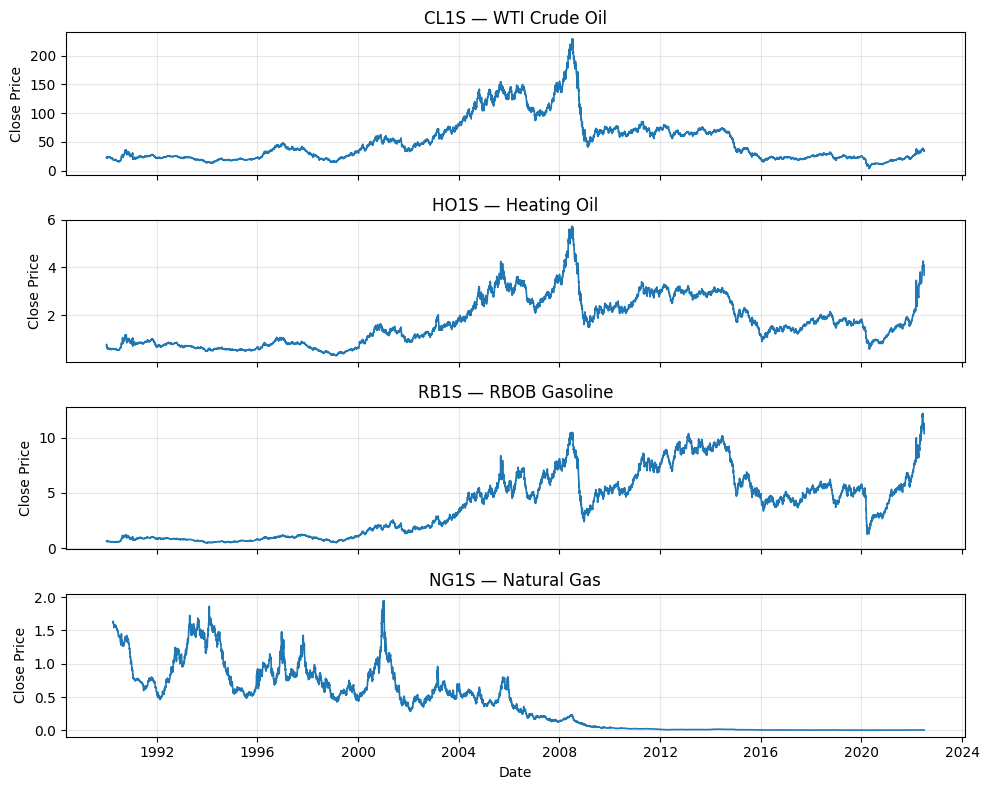

In [110]:
# ============================================================
# Historical Price Visualization
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

for ax, inst in zip(axes, ENERGY_INSTRUMENTS):

    df_inst = ohlcv_energy[
        ohlcv_energy["instrument"] == inst
    ]

    ax.plot(
        df_inst["date"],
        df_inst["close"],
        linewidth=1.2
    )

    ax.set_title(
        f"{inst.upper()} — {INSTRUMENT_NAMES[inst]}",
        fontsize=12
    )

    ax.set_ylabel("Close Price")

    ax.grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

## 1.6 Return Series Construction

Financial machine learning models are generally built on returns rather than raw price levels.

We therefore compute daily log returns for each instrument:

$$
r_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

Log returns are preferred because:
- they are additive through time,
- more statistically stable than prices,
- and largely invariant to the absolute price scale.

This is particularly important for futures contracts, where continuous-contract adjustments may distort long-term price levels.

In [111]:
# ============================================================
# Daily Log Returns
# ============================================================

ohlcv_energy["log_return"] = (
    ohlcv_energy
    .groupby("instrument")["close"]
    .transform(lambda x: np.log(x / x.shift(1)))
)

display(
    ohlcv_energy[
        ["date", "instrument", "close", "log_return"]
    ].head(10)
)

,date,instrument,close,log_return
0,1990-01-02,cl1s,22.89,NaN
1,1990-01-03,cl1s,23.68,0.033931
2,1990-01-04,cl1s,23.41,-0.011468
3,1990-01-05,cl1s,23.08,-0.014197
4,1990-01-08,cl1s,21.62,-0.065348
5,1990-01-09,cl1s,22.07,0.020600
6,1990-01-10,cl1s,22.90,0.036918
7,1990-01-11,cl1s,23.14,0.010426
8,1990-01-12,cl1s,23.13,-0.000432
9,1990-01-15,cl1s,22.36,-0.033857


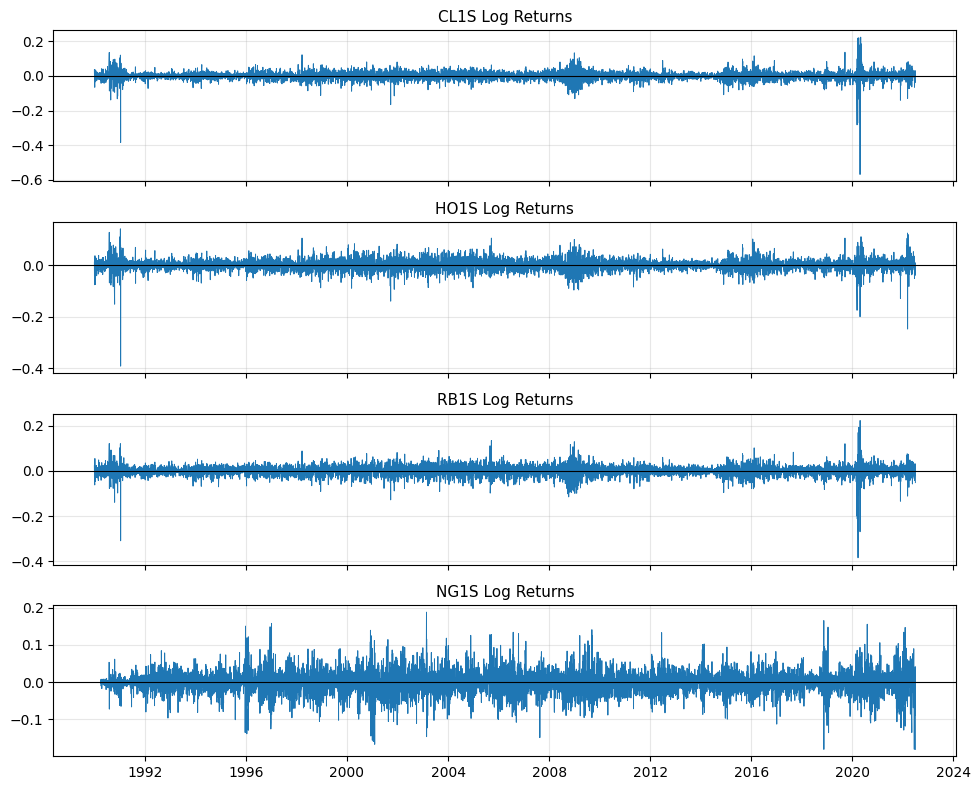

In [112]:
# ============================================================
# Log Return Visualization
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(10, 8),
    sharex=True
)

for ax, inst in zip(axes, ENERGY_INSTRUMENTS):

    df_inst = ohlcv_energy[
        ohlcv_energy["instrument"] == inst
    ]

    ax.plot(
        df_inst["date"],
        df_inst["log_return"],
        linewidth=0.7
    )

    ax.set_title(
        f"{inst.upper()} Log Returns",
        fontsize=11
    )

    ax.axhline(0, color="black", linewidth=0.8)

    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 1.7 Reshaping Primary Signals

The primary signal dataset is currently stored in a wide format:

| date | cl1s | ho1s | rb1s | ng1s |
|---|---|---|---|---|

However, the OHLCV dataset is stored in long format:

| date | instrument | open | high | low | close | ... |

To simplify merging and downstream processing, we reshape the signal dataset into long format using `pandas.melt()`.

The resulting structure becomes:

| date | instrument | signal |
|---|---|---|

This representation is much more convenient for:
- feature engineering,
- labeling,
- merging datasets,
- and machine learning pipelines.

In [113]:
# ============================================================
# Reshape Signals to Long Format
# ============================================================

signals_long = signals_energy.melt(
    id_vars="date",
    value_vars=ENERGY_INSTRUMENTS,
    var_name="instrument",
    value_name="primary_signal"
)

signals_long = (
    signals_long
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Signals long shape:", signals_long.shape)

display(signals_long.head(10))

Signals long shape: (2580, 3)


,date,instrument,primary_signal
0,2020-01-03,cl1s,0
1,2020-01-06,cl1s,0
2,2020-01-07,cl1s,-1
3,2020-01-08,cl1s,0
4,2020-01-09,cl1s,0
5,2020-01-10,cl1s,0
6,2020-01-13,cl1s,0
7,2020-01-14,cl1s,0
8,2020-01-15,cl1s,0
9,2020-01-16,cl1s,0


# Phase 2 — Feature Engineering

In this phase, we construct predictive features from the Energy OHLCV dataset.

The objective is to describe the market environment in which each primary signal occurs.  
These features will later be used by the metamodel to estimate whether a given primary trading signal is worth taking.

We construct features separately for each instrument, using only past and current information available at each date.  
This is essential to avoid look-ahead bias.

The feature engineering process is organized into several blocks:

1. **Core return and momentum features**
   - daily returns,
   - rolling cumulative returns,
   - short-term and medium-term momentum.

2. **Volatility features**
   - rolling realized volatility,
   - volatility ratios,
   - volatility regime indicators.

3. **Volume and open-interest features**
   - volume changes,
   - volume z-scores,
   - open-interest changes.

4. **Technical indicators**
   - RSI,
   - MACD,
   - Bollinger-style z-scores.

5. **Time-series dependence features**
   - rolling autocorrelation,
   - volatility clustering proxies,
   - trend persistence measures.

6. **Cross-sectional features**
   - relative momentum,
   - relative volatility,
   - ranks within the Energy asset class.

7. **Latent regime features**
   - GMM/HMM-based regime probabilities,
   - market turbulence indicators.

At this stage, we start with a robust set of core statistical features before adding more advanced indicators.

## 2.1 Core Return and Momentum Features

We begin with a set of core return-based and momentum features.

Momentum features aim to capture whether an instrument has recently experienced persistent positive or negative price movements.  
Such features are widely used in systematic trading strategies, where trend-following and persistence effects often play an important role.

For each instrument, we compute rolling momentum over several horizons:

$$
\text{mom}_{k,t}
=
\log\left(\frac{P_t}{P_{t-k}}\right)
$$

where:
- \(P_t\) is the closing price at time \(t\),
- and \(k\) represents the lookback horizon.

We use multiple horizons in order to capture:
- short-term momentum,
- medium-term trends,
- and longer-term price persistence.

In addition, we compute rolling average returns:

$$
\bar r_t^{(k)}
=
\frac{1}{k}
\sum_{i=0}^{k-1} r_{t-i}
$$

which provide smoother estimates of recent market direction and local return persistence.

All features are computed independently for each instrument using:

```python
groupby("instrument")

In [114]:
# ============================================================
# Phase 2 — Feature Engineering Setup
# ============================================================

features_df = ohlcv_energy.copy()

# Make sure data is sorted before computing rolling/grouped features
features_df = (
    features_df
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Feature engineering base shape:", features_df.shape)
display(features_df.head())

Feature engineering base shape: (32614, 9)


,date,instrument,open,high,low,close,volume,open_interest,log_return
0,1990-01-02,cl1s,21.80,22.92,21.79,22.89,22868.0,66308.0,NaN
1,1990-01-03,cl1s,23.20,23.80,23.00,23.68,45177.0,61428.0,0.033931
2,1990-01-04,cl1s,23.88,23.92,22.83,23.41,50061.0,60995.0,-0.011468
3,1990-01-05,cl1s,23.42,23.70,23.03,23.08,53070.0,57258.0,-0.014197
4,1990-01-08,cl1s,22.60,22.60,21.55,21.62,39720.0,54644.0,-0.065348


In [115]:
# ==============================================================================
# PHASE 2 - UNIFIED ADVANCED FEATURE ENGINEERING (TALIB & PRADO FRAMEWORK)
# ==============================================================================
import numpy as np
import pandas as pd
import talib
import scipy.stats as stats
import statsmodels.tsa.stattools as ts
from joblib import Parallel, delayed


# ==============================================================================
# FONCTIONS PRADO
# ==============================================================================

def calculate_sharpe_ratio(returns, rf_rate=0.0, periods=252, annualized=True):
    excess = returns - rf_rate
    std = excess.std(ddof=1)
    if std == 0 or np.isnan(std): return np.nan
    sr = excess.mean() / std
    return sr * np.sqrt(periods) if annualized else sr

def calculate_sortino_ratio(returns, rf_rate=0.0, periods=252, annualized=True):
    excess = returns - rf_rate
    downside = excess[excess < 0]
    if len(downside) < 2: return np.nan
    downside_std = np.sqrt(np.mean(downside**2))
    if downside_std == 0 or np.isnan(downside_std): return np.nan
    sortino = excess.mean() / downside_std
    return sortino * np.sqrt(periods) if annualized else sortino

def calculate_probabilistic_sharpe_ratio(returns, benchmark_sr=0.0, periods=252):
    t = len(returns)
    if t < 5: return np.nan
    sr_est = calculate_sharpe_ratio(returns, annualized=False)
    if np.isnan(sr_est): return np.nan
    sr_bench = benchmark_sr / np.sqrt(periods)
    skew = returns.skew()
    kurt = returns.kurtosis() + 3
    denom = 1.0 - skew * sr_est + ((kurt - 1.0) / 4.0) * sr_est**2
    if denom <= 0: return np.nan
    std_sr = np.sqrt(denom / (t - 1.0))
    return stats.norm.cdf((sr_est - sr_bench) / std_sr)

def calculate_deflated_sharpe_ratio(returns, all_trial_sharpes, periods=252):
    n = len(all_trial_sharpes)
    if n <= 1:
        return calculate_probabilistic_sharpe_ratio(returns, benchmark_sr=0.0, periods=periods)
    deann = all_trial_sharpes / np.sqrt(periods)
    var_sr = np.var(deann, ddof=1)
    ec = 0.5772156649
    z_n  = stats.norm.ppf(1.0 - 1.0 / n)
    z_ne = stats.norm.ppf(1.0 - 1.0 / (n * np.e))
    expected_max = np.sqrt(var_sr) * ((1 - ec) * z_n + ec * z_ne)
    return calculate_probabilistic_sharpe_ratio(returns, benchmark_sr=expected_max * np.sqrt(periods), periods=periods)

def cusum_filter(prices, threshold):
    s_pos = s_neg = 0.0
    events = []
    for date, ret in np.log(prices / prices.shift(1)).dropna().items():
        s_pos = max(0.0, s_pos + ret)
        s_neg = min(0.0, s_neg + ret)
        if s_pos > threshold:
            s_pos = 0.0; events.append(date)
        elif s_neg < -threshold:
            s_neg = 0.0; events.append(date)
    return pd.Index(events)

def lempel_ziv_complexity(seq):
    i, c, u, v, v_max, n = 0, 1, 1, 1, 1, len(seq)
    if n == 0: return 0
    while u + v <= n:
        if seq[i + v - 1] == seq[u + v - 1]:
            v += 1
        else:
            v_max = max(v_max, v); i += 1
            if i == u:
                c += 1; u += v_max; v = v_max = 1; i = 0
            else:
                v = 1
    return c + (v != 1)

def frac_diff_ffd(series, d, thres=1e-5):
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < thres: break
        w.append(w_k); k += 1
    w = np.array(w[::-1]); width = len(w) - 1
    out = pd.Series(index=series.index, dtype=float)
    for i in range(width, len(series)):
        out.iloc[i] = np.dot(w, series.iloc[i - width:i + 1].values)
    return out

def shannon_entropy_vectorized(series, window, bins=10):
    arr = series.values
    result = np.full(len(arr), np.nan)
    for i in range(window - 1, len(arr)):
        x = arr[i - window + 1:i + 1]
        x = x[~np.isnan(x)]
        if len(x) == 0: continue
        hist, _ = np.histogram(x, bins=bins)
        p = hist[hist > 0].astype(float); p /= p.sum()
        result[i] = -np.sum(p * np.log2(p))
    return pd.Series(result, index=series.index)

def lz_rolling_fast(series, window):
    binary = (series.values > 0).astype(int)
    result = np.full(len(binary), np.nan)
    for i in range(window - 1, len(binary)):
        seq = ''.join(map(str, binary[i - window + 1:i + 1]))
        result[i] = lempel_ziv_complexity(seq)
    return pd.Series(result, index=series.index)

def sadf_rolling(close, step=5):
    """SADF calculé tous les `step` jours puis forward-fillé — x5 plus rapide."""
    sadf_vals = np.full(len(close), np.nan)
    for i in range(25, len(close), step):
        window = close.iloc[max(0, i - 252):i].values
        try:
            sadf_vals[i] = ts.adfuller(window, maxlag=1, autolag=None)[0]
        except Exception:
            pass
    out = pd.Series(sadf_vals, index=close.index)
    return out.ffill()


# ==============================================================================
# FONCTION PRINCIPALE PAR INSTRUMENT (pour joblib)
# ==============================================================================

def compute_instrument_features(name, df):
    print(f"  → {name}...")

    # --- Microstructure ---
    df['hl_spread']      = (df['high'] - df['low']) / df['close']
    df['oc_spread']      = (df['close'] - df['open']) / df['open']
    df['close_position'] = (df['close'] - df['low']) / (df['high'] - df['low'])

    # --- Returns ---
    df['returns']    = df['close'].pct_change()
    df['log_return'] = np.log(df['close'] / df['close'].shift(1))

    # --- Multi-horizon : returns, vol, momentum, RSI, MOM ---
    for h in [5, 10, 20, 60]:
        df[f'returns_{h}']       = df['close'].pct_change(h)
        df[f'vol_{h}']           = df['returns'].rolling(h).std()
        df[f'momentum_{h}d']     = np.log(df['close'] / df['close'].shift(h))
        df[f'realized_vol_{h}d'] = df['log_return'].rolling(h).std()
        df[f'rsi_{h}']           = talib.RSI(df['close'].values, timeperiod=h)
        df[f'mom_{h}']           = talib.MOM(df['close'].values, timeperiod=h)
        if h in [5, 20, 60]:
            df[f'mean_return_{h}d'] = df['log_return'].rolling(h).mean()

    # --- Volatilité avancée ---
    df['vol_parkinson_20d']       = np.sqrt((np.log(df['high'] / df['low'])**2 / (4 * np.log(2))).rolling(20).mean())
    gk = 0.5 * np.log(df['high'] / df['low'])**2 - (2*np.log(2)-1) * np.log(df['close'] / df['open'])**2
    df['vol_garman_klass_20d']    = np.sqrt(gk.clip(lower=0).rolling(20).mean())
    rs = (np.log(df['high']/df['close']) * np.log(df['high']/df['open'])
        + np.log(df['low'] /df['close']) * np.log(df['low'] /df['open']))
    df['vol_rogers_satchell_20d'] = np.sqrt(rs.clip(lower=0).rolling(20).mean())
    df['atr_14']                  = talib.ATR(df['high'].values, df['low'].values, df['close'].values, timeperiod=14)
    upper, mid, lower_bb          = talib.BBANDS(df['close'].values, timeperiod=20)
    df['bb_width']                = (upper - lower_bb) / mid
    df['bb_position']             = (df['close'].values - lower_bb) / (upper - lower_bb)
    df['vol_ratio_20_60']         = df['realized_vol_20d'] / df['realized_vol_60d'].replace(0, np.nan)
    df['ewma_vol_10d']            = df['log_return'].ewm(span=10, adjust=False).std()
    df['ewma_vol_20d']            = df['log_return'].ewm(span=20, adjust=False).std()

    # --- Momentum / oscillateurs ---
    macd, macdsig, macdhist = talib.MACD(df['close'].values)
    df['macd']        = macd
    df['macd_signal'] = macdsig
    df['macd_hist']   = macdhist
    df['stoch_k'], df['stoch_d'] = talib.STOCH(df['high'].values, df['low'].values, df['close'].values)
    df['willr_14']    = talib.WILLR(df['high'].values, df['low'].values, df['close'].values, timeperiod=14)
    df['rsi_14']      = talib.RSI(df['close'].values, timeperiod=14)
    df['adx_14']      = talib.ADX(df['high'].values, df['low'].values, df['close'].values, timeperiod=14)

    # --- Distance aux SMA ---
    for h in [10, 50, 200]:
        sma = talib.SMA(df['close'].values, timeperiod=h)
        df[f'close_to_sma_{h}'] = df['close'].values / sma - 1
    df['distance_from_200d_ma'] = (df['close'].values - talib.SMA(df['close'].values, 200)) \
                                  / df['log_return'].rolling(60).std().replace(0, np.nan)

    # --- Volume & Open Interest ---
    df['obv']               = talib.OBV(df['close'].values, df['volume'].values)
    df['obv_chg_20']        = pd.Series(df['obv'], index=df.index).pct_change(20).values
    df['mfi_14']            = talib.MFI(df['high'].values, df['low'].values, df['close'].values, df['volume'].values, timeperiod=14)
    df['volume_zscore_20d'] = (df['volume'] - df['volume'].rolling(20).mean()) / df['volume'].rolling(20).std().replace(0, np.nan)
    df['log_volume_change'] = np.log(df['volume'] / df['volume'].shift(1).replace(0, np.nan))
    df['oi_change']         = df['open_interest'].pct_change()
    df['oi_momentum_20d']   = np.log(df['open_interest'] / df['open_interest'].shift(20).replace(0, np.nan))
    df['vol_oi_ratio']      = df['volume'] / df['open_interest'].replace(0, np.nan)

    # --- Distribution & autocorrélation ---
    df['skew_20']             = df['returns'].rolling(20).skew()
    df['kurt_20']             = df['returns'].rolling(20).kurt()
    df['skew_60']             = df['returns'].rolling(60).skew()
    df['autocorr_return_20d'] = df['returns'].rolling(20).apply(lambda x: x.autocorr(1) if x.dropna().shape[0] >= 10 else np.nan, raw=False)
    df['autocorr_abs_ret_20d']= df['returns'].abs().rolling(20).apply(lambda x: x.autocorr(1) if x.dropna().shape[0] >= 10 else np.nan, raw=False)
    df['autocorr_return_60d'] = df['returns'].rolling(60).apply(lambda x: x.autocorr(1) if x.dropna().shape[0] >= 20 else np.nan, raw=False)

    # --- Z-scores & ratio haussier ---
    df['price_zscore_20d']          = (df['close'] - df['close'].rolling(20).mean()) / df['close'].rolling(20).std().replace(0, np.nan)
    df['price_zscore_60d']          = (df['close'] - df['close'].rolling(60).mean()) / df['close'].rolling(60).std().replace(0, np.nan)
    df['positive_return_ratio_10d'] = (df['log_return'] > 0).rolling(10).mean()
    df['positive_return_ratio_20d'] = (df['log_return'] > 0).rolling(20).mean()

    # --- Fractional différentiation ---
    df['close_fracdiff'] = frac_diff_ffd(df['close'], d=0.4)

    # --- Complexity & Régime (Prado) ---
    df['sadf']                = sadf_rolling(df['close'], step=5)          # bulles/régimes
    df['shannon_entropy_20d'] = shannon_entropy_vectorized(df['returns'], 20)  # désordre 20j
    df['shannon_entropy_60d'] = shannon_entropy_vectorized(df['returns'], 60)  # désordre 60j
    df['lz_complexity_20d']   = lz_rolling_fast(df['returns'], 20)         # complexité 20j
    df['lz_complexity_60d']   = lz_rolling_fast(df['returns'], 60)         # complexité 60j

    return name, df


# ==============================================================================
# 1. INITIALISATION
# ==============================================================================
instruments = ["cl1s", "ho1s", "rb1s", "ng1s"]
name_map    = {"cl1s": "WTI", "ho1s": "Heating_oil", "rb1s": "RBOB", "ng1s": "Nat_gas"}
inv_name_map = {v: k for k, v in name_map.items()}

features_df = ohlcv_energy.copy().sort_values(["instrument", "date"]).reset_index(drop=True)
features_df.replace([np.inf, -np.inf], np.nan, inplace=True)

commo = {name_map[tk]: features_df[features_df["instrument"] == tk].set_index("date").copy()
         for tk in instruments}


# ==============================================================================
# 2. FEATURES PAR INSTRUMENT — parallélisé (4 jobs)
# ==============================================================================
print("Calcul des features par instrument (parallel)...")
results = Parallel(n_jobs=4, prefer="threads")(
    delayed(compute_instrument_features)(name, df.copy())
    for name, df in commo.items()
)
commo = {name: df for name, df in results}


# ==============================================================================
# 3. FEATURES CROSS-ASSET
# ==============================================================================
closes      = pd.DataFrame({n: d['close'] for n, d in commo.items()})
returns_all = closes.pct_change()

mom_20 = pd.DataFrame({n: commo[n]['momentum_20d'] for n in commo})
mom_60 = pd.DataFrame({n: commo[n]['momentum_60d'] for n in commo})
vol_20 = pd.DataFrame({n: commo[n]['realized_vol_20d'] for n in commo})
vol_60 = pd.DataFrame({n: commo[n]['realized_vol_60d'] for n in commo})

for name in commo:
    basket = returns_all[[c for c in commo if c != name]].mean(axis=1)
    commo[name]['corr_basket_20']                = returns_all[name].rolling(20).corr(basket)
    commo[name]['corr_basket_60']                = returns_all[name].rolling(60).corr(basket)
    commo[name]['momentum_rank_20d']             = mom_20.rank(axis=1, pct=True)[name]
    commo[name]['momentum_rank_60d']             = mom_60.rank(axis=1, pct=True)[name]
    commo[name]['relative_vol_20d']              = commo[name]['realized_vol_20d'] / vol_20.mean(axis=1).replace(0, np.nan)
    commo[name]['relative_vol_60d']              = commo[name]['realized_vol_60d'] / vol_60.mean(axis=1).replace(0, np.nan)
    commo[name]['sector_momentum_dispersion_20d']= mom_20.std(axis=1)
    commo[name]['sector_momentum_dispersion_60d']= mom_60.std(axis=1)
    commo[name]['sector_vol_dispersion_20d']     = vol_20.std(axis=1)
    commo[name]['relative_momentum_20d']         = commo[name]['momentum_20d'] - mom_20.mean(axis=1)

# Crack spreads WTI
commo['WTI']['crack_rb'] = closes['RBOB']        / closes['WTI'] - 1
commo['WTI']['crack_ho'] = closes['Heating_oil'] / closes['WTI'] - 1


# ==============================================================================
# 4. RECONSTRUCTION DU PANEL features_df
# ==============================================================================
features_df = (pd.concat([commo[n].reset_index().assign(instrument=inv_name_map[n]) for n in commo])
               .sort_values(["instrument", "date"])
               .reset_index(drop=True))
features_df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f"\nFeature engineering complet — {len(features_df.columns)} features | shape: {features_df.shape}")
display(features_df.head(25))


Calcul des features par instrument (parallel)...
  → Heating_oil...
  → WTI...
  → RBOB...
  → Nat_gas...

Feature engineering complet — 97 features | shape: (32614, 97)


/var/folders/r7/dpqwlxxn77ggc8rng8ygccmc0000gn/T/ipykernel_93901/64563408.py:253: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_all = closes.pct_change()


,date,instrument,open,high,low,close,volume,open_interest,log_return,hl_spread,oc_spread,close_position,returns,returns_5,vol_5,momentum_5d,realized_vol_5d,rsi_5,mom_5,mean_return_5d,returns_10,vol_10,momentum_10d,realized_vol_10d,rsi_10,mom_10,returns_20,vol_20,momentum_20d,realized_vol_20d,rsi_20,mom_20,mean_return_20d,returns_60,vol_60,momentum_60d,realized_vol_60d,rsi_60,mom_60,mean_return_60d,vol_parkinson_20d,vol_garman_klass_20d,vol_rogers_satchell_20d,atr_14,bb_width,bb_position,vol_ratio_20_60,ewma_vol_10d,ewma_vol_20d,macd,macd_signal,macd_hist,stoch_k,stoch_d,willr_14,rsi_14,adx_14,close_to_sma_10,close_to_sma_50,close_to_sma_200,distance_from_200d_ma,obv,obv_chg_20,mfi_14,volume_zscore_20d,log_volume_change,oi_change,oi_momentum_20d,vol_oi_ratio,skew_20,kurt_20,skew_60,autocorr_return_20d,autocorr_abs_ret_20d,autocorr_return_60d,price_zscore_20d,price_zscore_60d,positive_return_ratio_10d,positive_return_ratio_20d,close_fracdiff,sadf,shannon_entropy_20d,shannon_entropy_60d,lz_complexity_20d,lz_complexity_60d,corr_basket_20,corr_basket_60,momentum_rank_20d,momentum_rank_60d,relative_vol_20d,relative_vol_60d,sector_momentum_dispersion_20d,sector_momentum_dispersion_60d,sector_vol_dispersion_20d,relative_momentum_20d,crack_rb,crack_ho
0,1990-01-02,cl1s,21.800000,22.920000,21.790000,22.890000,22868.000000,66308.000000,NaN,0.049367,0.050000,0.973451,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22868.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.344875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.971302,-0.966190
1,1990-01-03,cl1s,23.200000,23.800000,23.000000,23.680000,45177.000000,61428.000000,0.033931,0.033784,0.020690,0.850000,0.034513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,68045.000000,NaN,NaN,NaN,0.680850,-0.073596,NaN,0.735446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.971609,-0.966976
2,1990-01-04,cl1s,23.880000,23.920000,22.830000,23.410000,50061.000000,60995.000000,-0.011468,0.046561,-0.019682,0.532110,-0.011402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.032101,0.032101,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17984.000000,NaN,NaN,NaN,0.102654,-0.007049,NaN,0.820739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.972110,-0.968736
3,1990-01-05,cl1s,23.420000,23.700000,23.030000,23.080000,53070.000000,57258.000000,-0.014197,0.029029,-0.014518,0.074627,-0.014097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.031324,0.032253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-35086.000000,NaN,NaN,NaN,0.058370,-0.061267,NaN,0.926857,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.973042,-0.970611
4,1990-01-08,cl1s,22.600000,22.600000,21.550000,21.620000,39720.000000,54644.000000,-0.065348,0.048566,-0.043363,0.066667,-0.063258,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.047855,0.048410,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-74806.000000,NaN,NaN,NaN,-0.289757,-0.045653,NaN,0.726887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.972951,-0.970245
5,1990-01-09,cl1s,21.500000,22.120000,21.480000,22.070000,50051.000000,51669.000000,0.020600,0.028999,0.026512,0.921875,0.020814,-0.035824,0.037852,-0.036481,0.038448,37.575758,-0.820000,-0.007296,NaN,NaN,N

In [116]:
# ============================================================
# Feature Set Summary
# ============================================================

feature_columns = [
    col for col in features_df.columns
    if col not in [
        "date", "instrument", "open", "high", "low", "close",
        "volume", "open_interest"
    ]
]

print("Number of engineered features:", len(feature_columns))
print("\nFeature columns:")
for col in feature_columns:
    print("-", col)

missing_summary = (
    features_df[feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_ratio")
)

display(missing_summary.head(30))

Number of engineered features: 89

Feature columns:
- log_return
- hl_spread
- oc_spread
- close_position
- returns
- returns_5
- vol_5
- momentum_5d
- realized_vol_5d
- rsi_5
- mom_5
- mean_return_5d
- returns_10
- vol_10
- momentum_10d
- realized_vol_10d
- rsi_10
- mom_10
- returns_20
- vol_20
- momentum_20d
- realized_vol_20d
- rsi_20
- mom_20
- mean_return_20d
- returns_60
- vol_60
- momentum_60d
- realized_vol_60d
- rsi_60
- mom_60
- mean_return_60d
- vol_parkinson_20d
- vol_garman_klass_20d
- vol_rogers_satchell_20d
- atr_14
- bb_width
- bb_position
- vol_ratio_20_60
- ewma_vol_10d
- ewma_vol_20d
- macd
- macd_signal
- macd_hist
- stoch_k
- stoch_d
- willr_14
- rsi_14
- adx_14
- close_to_sma_10
- close_to_sma_50
- close_to_sma_200
- distance_from_200d_ma
- obv
- obv_chg_20
- mfi_14
- volume_zscore_20d
- log_volume_change
- oi_change
- oi_momentum_20d
- vol_oi_ratio
- skew_20
- kurt_20
- skew_60
- autocorr_return_20d
- autocorr_abs_ret_20d
- autocorr_return_60d
- price_zscore_20d


,missing_ratio
crack_ho,0.749525
crack_rb,0.749494
close_fracdiff,0.178696
close_to_sma_200,0.024407
distance_from_200d_ma,0.024407
oi_momentum_20d,0.017876
log_volume_change,0.011743
oi_change,0.008187
vol_oi_ratio,0.008064
skew_60,0.007359


## 2.8 HMM/GMM Regime Features


#### Couche PCA avant GMM / HMM

In [117]:
PCA_FEATURES = [
    # Volatilité (1-2 max, pas 6)
    'realized_vol_20d',
    'vol_ratio_20_60',          # capture la dynamique, pas le niveau

    # Momentum / tendance (2-3)
    'momentum_20d',
    'momentum_60d',
    'adx_14',                   # force de tendance

    # Mean reversion / position
    'close_to_sma_50',
    'bb_width',

    # Volume / liquidité
    'volume_zscore_20d',
    'vol_oi_ratio',

    # Distribution / risque de queue
    'skew_20',
    'kurt_20',

    # Régime Prado
    'sadf',
    'shannon_entropy_20d',

    # Cross-asset
    'corr_basket_20',
]

In [118]:
# ============================================================
# HMM Setup
# ============================================================

try:
    from hmmlearn.hmm import GaussianHMM
    print("hmmlearn is already installed.")
except ImportError:
    print("hmmlearn is not installed. Run the next cell:")
    print("!pip install hmmlearn")

hmmlearn is already installed.


### 2.8.2 Define Train/Test Split for HMM

Before fitting the HMM, we define a chronological train/test split using the primary signal dates.

For each instrument, the first 80% of signal dates are assigned to the training period, while the last 20% are reserved as the final out-of-sample test period.

The HMM is then fitted only using market data up to the last training signal date for each instrument.

In [119]:
# ============================================================
# Initialize HMM outputs
# ============================================================
N_HMM_STATES = 3
from sklearn.preprocessing import StandardScaler

features_df["hmm_regime"] = np.nan

for state in range(N_HMM_STATES):
    features_df[f"hmm_prob_state_{state}"] = np.nan

In [120]:
# ============================================================
# Define chronological 80/20 split from primary signals
# ============================================================

TEST_SIZE = 0.20

signal_split_info = {}

for instrument in ENERGY_INSTRUMENTS:
    
    signal_dates = (
        signals_long
        .loc[signals_long["instrument"] == instrument, "date"]
        .sort_values()
        .drop_duplicates()
        .reset_index(drop=True)
    )
    
    split_idx = int(len(signal_dates) * (1 - TEST_SIZE))
    
    train_dates = signal_dates.iloc[:split_idx]
    test_dates = signal_dates.iloc[split_idx:]
    
    signal_split_info[instrument] = {
        "n_dates": len(signal_dates),
        "n_train_dates": len(train_dates),
        "n_test_dates": len(test_dates),
        "train_start": train_dates.min(),
        "train_end": train_dates.max(),
        "test_start": test_dates.min(),
        "test_end": test_dates.max()
    }

split_summary = pd.DataFrame(signal_split_info).T
display(split_summary)

,n_dates,n_train_dates,n_test_dates,train_start,train_end,test_start,test_end
cl1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
ho1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
rb1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00
ng1s,645,516,129,2020-01-03 00:00:00,2021-12-30 00:00:00,2021-12-31 00:00:00,2022-06-30 00:00:00


### 2.8.3 Train One HMM per Instrument

We fit one Gaussian HMM per energy instrument.

Each HMM is trained only on the training period and then used to infer latent regimes over the full sample.

The inferred regimes will later be used as additional features for the metamodel.

In [121]:
# ============================================================
# Initialize HMM outputs
# ============================================================

from sklearn.preprocessing import StandardScaler

features_df["hmm_regime"] = np.nan

for state in range(N_HMM_STATES):
    features_df[f"hmm_prob_state_{state}"] = np.nan

cl1s       | 3 PCs : 51.0% | 5 PCs : 68.4% | → retenu : 5 composantes (68.4% variance)
ho1s       | 3 PCs : 51.0% | 5 PCs : 68.0% | → retenu : 5 composantes (68.0% variance)
rb1s       | 3 PCs : 50.2% | 5 PCs : 67.1% | → retenu : 5 composantes (67.1% variance)
ng1s       | 3 PCs : 47.9% | 5 PCs : 65.9% | → retenu : 5 composantes (65.9% variance)


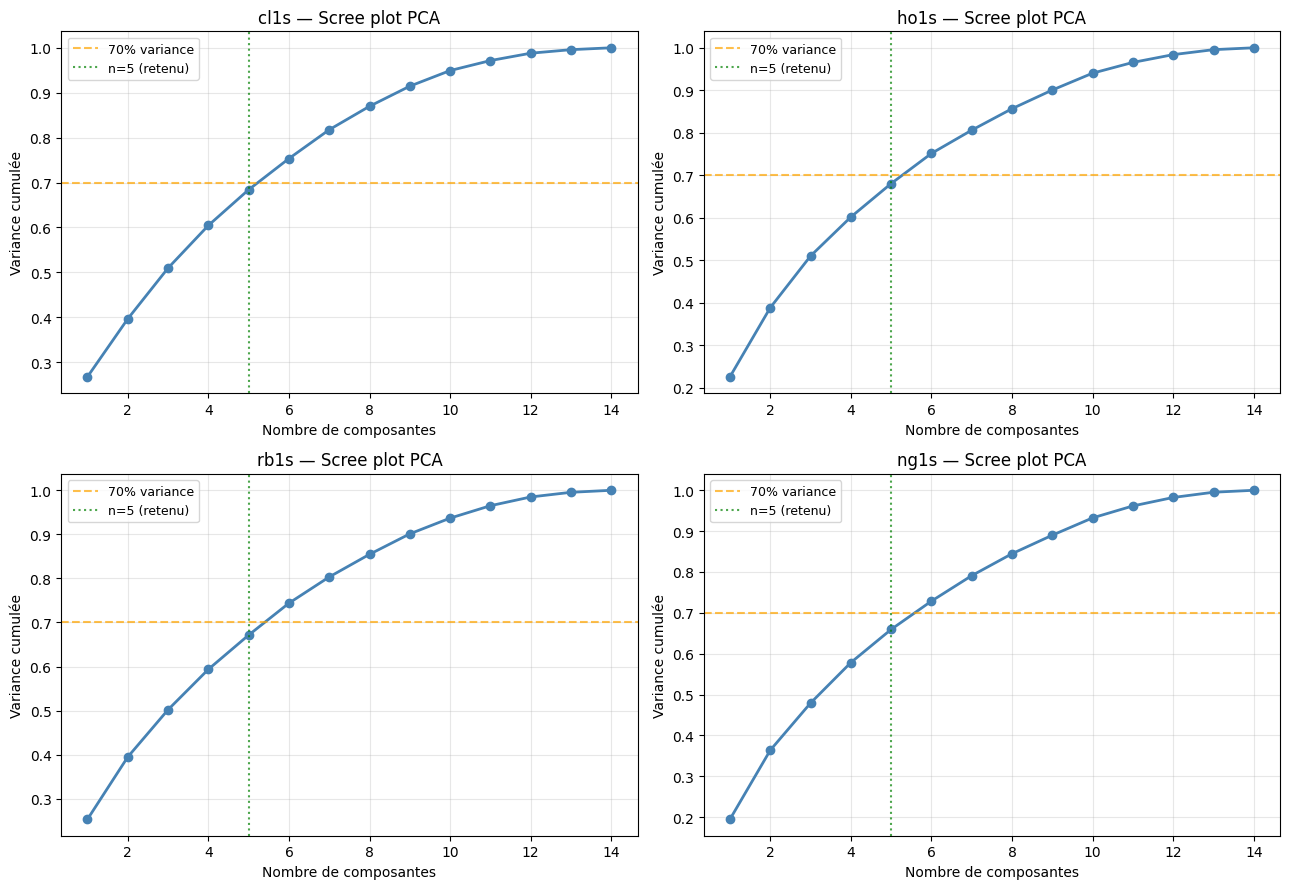


→ PCA_OUTPUTS = ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4']
→ Ces 5 colonnes sont maintenant dans features_df et prêtes pour HMM/GMM.
Justification : compromis entre rétention d'information et parcimonie.
Le HMM/GMM bénéficie d'inputs décorrélés (orthogonalité du PCA) et de basse dimension.


In [122]:
# ============================================================
# CELL 1bis — APPLIQUER LE PCA & PRÉPARER LES INPUTS HMM/GMM
# ============================================================

# Nombre fixe de composantes PCA à utiliser comme inputs HMM/GMM
N_PCA_COMPONENTS = 5

# Stockage des scalers et PCAs par instrument
pca_scalers = {}
pca_models  = {}

# Noms des colonnes PCA dans features_df (inputs du HMM/GMM)
PCA_OUTPUTS = [f"pca_{i}" for i in range(N_PCA_COMPONENTS)]

# Initialiser les colonnes PCA dans features_df
for col in PCA_OUTPUTS:
    features_df[col] = np.nan

# Plot setup
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, instrument in enumerate(ENERGY_INSTRUMENTS):

    # --------------------------------------------------------
    # Subset instrument & dropna sur les features bruts
    # --------------------------------------------------------
    instrument_df = (
        features_df.loc[features_df["instrument"] == instrument]
        .sort_values("date").copy()
    )
    instrument_df = instrument_df.dropna(subset=PCA_FEATURES)

    # --------------------------------------------------------
    # Train slice (fit uniquement sur train)
    # --------------------------------------------------------
    train_end_date = signal_split_info[instrument]["train_end"]
    train_df = instrument_df.loc[instrument_df["date"] <= train_end_date]

    # --------------------------------------------------------
    # Standardisation + PCA sur les 5 premières composantes
    # --------------------------------------------------------
    scaler = StandardScaler().fit(train_df[PCA_FEATURES].values)
    X_train_scaled = scaler.transform(train_df[PCA_FEATURES].values)
    X_full_scaled  = scaler.transform(instrument_df[PCA_FEATURES].values)

    pca = PCA(n_components=N_PCA_COMPONENTS)
    pca.fit(X_train_scaled)
    X_full_pca = pca.transform(X_full_scaled)

    pca_scalers[instrument] = scaler
    pca_models[instrument]  = pca

    # --------------------------------------------------------
    # Écrire les 5 composantes PCA dans features_df
    # --------------------------------------------------------
    for j, col in enumerate(PCA_OUTPUTS):
        features_df.loc[instrument_df.index, col] = X_full_pca[:, j]

    # --------------------------------------------------------
    # Plot scree (variance cumulée complète pour justification)
    # --------------------------------------------------------
    pca_full = PCA().fit(X_train_scaled)
    cumvar = np.cumsum(pca_full.explained_variance_ratio_)
    var_kept = pca.explained_variance_ratio_.sum()

    ax = axes[i]
    ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', linewidth=2, color='steelblue')
    ax.axhline(0.70, color='orange', linestyle='--', alpha=0.7, label='70% variance')
    ax.axvline(N_PCA_COMPONENTS, color='green', linestyle=':', alpha=0.7,
               label=f'n={N_PCA_COMPONENTS} (retenu)')
    ax.set_xlabel('Nombre de composantes')
    ax.set_ylabel('Variance cumulée')
    ax.set_title(f'{instrument} — Scree plot PCA')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    print(f"{instrument:10s} | "
          f"3 PCs : {cumvar[2]:.1%} | "
          f"5 PCs : {cumvar[4]:.1%} | "
          f"→ retenu : {N_PCA_COMPONENTS} composantes ({var_kept:.1%} variance)")

plt.tight_layout()
plt.show()

print(f"\n→ PCA_OUTPUTS = {PCA_OUTPUTS}")
print(f"→ Ces {N_PCA_COMPONENTS} colonnes sont maintenant dans features_df et prêtes pour HMM/GMM.")
print("Justification : compromis entre rétention d'information et parcimonie.")
print("Le HMM/GMM bénéficie d'inputs décorrélés (orthogonalité du PCA) et de basse dimension.")


In [123]:
# ============================================================
# CELL 2 — TRAIN HMM ON PCA OUTPUTS
# ============================================================
from hmmlearn.hmm import GaussianHMM

# Initialiser les colonnes outputs HMM
features_df["hmm_regime"] = np.nan
for state in range(N_HMM_STATES):
    features_df[f"hmm_prob_state_{state}"] = np.nan

hmm_models = {}

for instrument in ENERGY_INSTRUMENTS:

    print(f"\nTraining HMM for {instrument}...")

    # --------------------------------------------------------
    # Instrument subset — on lit directement les colonnes PCA
    # --------------------------------------------------------
    instrument_df = (
        features_df
        .loc[features_df["instrument"] == instrument]
        .sort_values("date")
        .copy()
    )
    instrument_df = instrument_df.dropna(subset=PCA_OUTPUTS)

    # --------------------------------------------------------
    # Train/test cutoff
    # --------------------------------------------------------
    train_end_date = signal_split_info[instrument]["train_end"]
    train_mask = instrument_df["date"] <= train_end_date
    train_df = instrument_df.loc[train_mask]

    # --------------------------------------------------------
    # Extract matrices (déjà standardisées et PCA-transformées)
    # --------------------------------------------------------
    X_train = train_df[PCA_OUTPUTS].values
    X_full  = instrument_df[PCA_OUTPUTS].values

    # --------------------------------------------------------
    # Fit Gaussian HMM directement sur les composantes PCA
    # --------------------------------------------------------
    hmm = GaussianHMM(
        n_components=N_HMM_STATES,
        covariance_type="full",
        n_iter=300,
        random_state=42
    )
    hmm.fit(X_train)
    hmm_models[instrument] = hmm

    # --------------------------------------------------------
    # Infer regimes on full sample
    # --------------------------------------------------------
    hidden_states = hmm.predict(X_full)
    state_probs   = hmm.predict_proba(X_full)

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    features_df.loc[instrument_df.index, "hmm_regime"] = hidden_states
    for state in range(N_HMM_STATES):
        features_df.loc[
            instrument_df.index,
            f"hmm_prob_state_{state}"
        ] = state_probs[:, state]

    print("Done.")


# ============================================================
# Construction de la liste finale de features pour le metamodel
# ============================================================

# Outputs HMM (créés ci-dessus)
HMM_FEATURES = ["hmm_regime"] + [f"hmm_prob_state_{s}" for s in range(N_HMM_STATES)]

# Liste finale combinée : composantes PCA + outputs HMM
HMM_FEATURES = PCA_OUTPUTS + HMM_OUTPUTS

print(f"\nPCA_OUTPUTS  : {PCA_OUTPUTS}")
print(f"HMM_OUTPUTS  : {HMM_OUTPUTS}")
print(f"HMM_FEATURES : {HMM_FEATURES}")



Training HMM for cl1s...
Done.

Training HMM for ho1s...
Done.

Training HMM for rb1s...
Done.

Training HMM for ng1s...
Done.

PCA_OUTPUTS  : ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4']
HMM_OUTPUTS  : ['hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2']
HMM_FEATURES : ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2']


In [124]:
# ============================================================
# CELL 3 — TRAIN GMM ON PCA OUTPUTS
# ============================================================
N_GMM_STATES = 3

from sklearn.mixture import GaussianMixture

# Initialize GMM outputs in features_df
features_df["gmm_regime"] = np.nan
for state in range(N_GMM_STATES):
    features_df[f"gmm_prob_state_{state}"] = np.nan

gmm_models = {}

for instrument in ENERGY_INSTRUMENTS:

    print(f"\nTraining GMM for {instrument}...")

    # --------------------------------------------------------
    # Instrument subset — on lit directement les colonnes PCA
    # --------------------------------------------------------
    instrument_df = (
        features_df
        .loc[features_df["instrument"] == instrument]
        .sort_values("date")
        .copy()
    )
    instrument_df = instrument_df.dropna(subset=PCA_OUTPUTS)

    # --------------------------------------------------------
    # Train/test cutoff
    # --------------------------------------------------------
    train_end_date = signal_split_info[instrument]["train_end"]
    train_mask = instrument_df["date"] <= train_end_date
    train_df = instrument_df.loc[train_mask]

    # --------------------------------------------------------
    # Extract matrices (déjà standardisées et PCA-transformées)
    # --------------------------------------------------------
    X_train = train_df[PCA_OUTPUTS].values
    X_full  = instrument_df[PCA_OUTPUTS].values

    # --------------------------------------------------------
    # Fit Gaussian Mixture sur les composantes PCA
    # --------------------------------------------------------
    gmm = GaussianMixture(
        n_components=N_GMM_STATES,
        covariance_type="full",
        n_init=10,
        max_iter=300,
        random_state=42
    )
    gmm.fit(X_train)
    gmm_models[instrument] = gmm

    # --------------------------------------------------------
    # Infer regimes on full sample
    # --------------------------------------------------------
    gmm_states = gmm.predict(X_full)
    gmm_probs  = gmm.predict_proba(X_full)

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------
    features_df.loc[instrument_df.index, "gmm_regime"] = gmm_states
    for state in range(N_GMM_STATES):
        features_df.loc[
            instrument_df.index,
            f"gmm_prob_state_{state}"
        ] = gmm_probs[:, state]

    print("Done.")


# ============================================================
# Mise à jour de la liste finale de features pour le metamodel
# ============================================================

# Outputs GMM (créés ci-dessus)
GMM_OUTPUTS = ["gmm_regime"] + [f"gmm_prob_state_{s}" for s in range(N_GMM_STATES)]

# Liste finale combinée : composantes PCA + outputs HMM + outputs GMM
META_FEATURES = PCA_OUTPUTS + HMM_OUTPUTS + GMM_OUTPUTS

print(f"\nPCA_OUTPUTS   : {PCA_OUTPUTS}")
print(f"HMM_OUTPUTS   : {HMM_OUTPUTS}")
print(f"GMM_OUTPUTS   : {GMM_OUTPUTS}")
print(f"META_FEATURES : {META_FEATURES}")


Training GMM for cl1s...
Done.

Training GMM for ho1s...
Done.

Training GMM for rb1s...
Done.

Training GMM for ng1s...
Done.

PCA_OUTPUTS   : ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4']
HMM_OUTPUTS   : ['hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2']
GMM_OUTPUTS   : ['gmm_regime', 'gmm_prob_state_0', 'gmm_prob_state_1', 'gmm_prob_state_2']
META_FEATURES : ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'hmm_regime', 'hmm_prob_state_0', 'hmm_prob_state_1', 'hmm_prob_state_2', 'gmm_regime', 'gmm_prob_state_0', 'gmm_prob_state_1', 'gmm_prob_state_2']


### 2.8.4 Inspect HMM Regime Features

We now inspect the HMM regime features to verify that:

- each observation is assigned a regime,
- regime probabilities sum to one,
- regimes are used across instruments,
- and the inferred states can later be interpreted economically.

In [146]:
# ============================================================
# Inspect HMM + GMM feature columns
# ============================================================

display(
    features_df[
        ["date", "instrument"] + META_FEATURES
    ]
    .dropna(subset=hmm_cols)
    .head(20)
)

,date,instrument,pca_0,pca_1,pca_2,pca_3,pca_4,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2,gmm_regime,gmm_prob_state_0,gmm_prob_state_1,gmm_prob_state_2
60,1990-03-28,cl1s,0.350529,1.475194,-0.078521,-1.361758,0.162471,2.0,4.139433e-235,4.514118e-136,1.000000e+00,2.0,3.254226e-02,0.001105,0.966353
61,1990-03-29,cl1s,0.353975,1.671781,-0.105573,-0.871253,0.009756,2.0,1.594770e-06,2.091748e-03,9.979067e-01,2.0,2.560505e-02,0.001139,0.973255
62,1990-03-30,cl1s,0.573951,1.999867,0.057642,-0.489778,-0.046017,2.0,2.331341e-06,4.888749e-03,9.951089e-01,2.0,3.422137e-02,0.001486,0.964292
63,1990-04-02,cl1s,0.770889,1.912406,0.213349,-1.314104,0.255085,2.0,4.786130e-06,1.040585e-02,9.895894e-01,2.0,5.960929e-02,0.001349,0.939042
64,1990-04-03,cl1s,0.760398,1.722283,0.020249,-1.014051,0.148004,2.0,1.988195e-05,4.297267e-02,9.570075e-01,2.0,8.340077e-02,0.001114,0.915485
65,1990-04-04,cl1s,0.526778,2.027937,0.147183,-1.508564,0.392580,2.0,1.650023e-04,2.878239e-01,7.120110e-01,2.0,1.870209e-02,0.001780,0.979518
66,1990-04-05,cl1s,0.025318,1.795029,-0.292013,-0.381734,-0.192533,1.0,1.315615e-04,8.013154e-01,1.985531e-01,2.0,5.657611e-03,0.001563,0.992779
67,1990-04-06,cl1s,-0.109636,2.005375,-0.320344,0.305514,-0.397385,1.0,3.531806e-04,9.806129e-01,1.903393e-02,2.0,1.761169e-03,0.002561,0.995678
68,1990-04-09,cl1s,-0.802109,1.830270,-0.451388,-0.425453,0.310878,1.0,4.961702e-03,9.949387e-01,9.956314e-05,2.0,1.080103e-05,0.004490,0.995499
69,1990-04-10,cl1s,-1.485435,2.128112,-0.164867,-0.647504,0.437718,1.0,1.012074e-01,8.987926e-01,3.800689e-08,2.0,7.292991e-09,0.012956,0.987044


In [ ]:
# ============================================================
# Check HMM & GMM probability sums
# ============================================================
features_df["hmm_prob_sum"] = (
    features_df["hmm_prob_state_0"]
    + features_df["hmm_prob_state_1"]
    + features_df["hmm_prob_state_2"]
)


features_df["gmm_prob_sum"] = (
    features_df["gmm_prob_state_0"]
    + features_df["gmm_prob_state_1"]
    + features_df["gmm_prob_state_2"]
)

display(
    features_df[
        ["date", "instrument", "hmm_prob_sum", "gmm_prob_sum"]
    ]
    .dropna()
    .head(20)
)

print(
    "Min probability sum:",
    features_df["hmm_prob_sum"].min(),
    features_df["gmm_prob_sum"].min()
)

print(
    "Max probability sum:",
    features_df["hmm_prob_sum"].max(),
    features_df["gmm_prob_sum"].max()
)

,date,instrument,hmm_prob_sum,gmm_prob_sum
60,1990-03-28,cl1s,1.0,1.0
61,1990-03-29,cl1s,1.0,1.0
62,1990-03-30,cl1s,1.0,1.0
63,1990-04-02,cl1s,1.0,1.0
64,1990-04-03,cl1s,1.0,1.0
65,1990-04-04,cl1s,1.0,1.0
66,1990-04-05,cl1s,1.0,1.0
67,1990-04-06,cl1s,1.0,1.0
68,1990-04-09,cl1s,1.0,1.0
69,1990-04-10,cl1s,1.0,1.0


Min probability sum: 0.9999999999963625 0.9999999999999973
Max probability sum: 1.0000000000036378 1.0000000000000027


## 2.9 Merge Features with Primary Signals

We now merge the engineered feature set with the primary trading signals.

The resulting dataframe contains one row per `(date, instrument)` where the primary model provides a signal. This will become the base dataset used for triple-barrier labeling and later metamodel training.

At this stage, we keep both active signals (`+1`, `-1`) and inactive signals (`0`). The active signals will be used for labeling trades, while inactive signals ????.

In [160]:
# ============================================================
# Merge engineered features with primary signals
# ============================================================

model_base_df = (
    signals_long
    .merge(
        features_df,
        on=["date", "instrument"],
        how="left"
    )
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Model base dataframe shape:", model_base_df.shape)

display(
    model_base_df[
        [
            "date",
            "instrument",
            "primary_signal",
            "close",
            "log_return",
            "momentum_20d",
            "realized_vol_20d",
            "hmm_regime",
            "hmm_prob_state_0",
            "hmm_prob_state_1",
            "hmm_prob_state_2",
            "gmm_regime",
            "hmm_prob_state_0",
            "hmm_prob_state_1",
            "hmm_prob_state_2"
        ]
    ].head(20)
)

Model base dataframe shape: (2580, 113)


,date,instrument,primary_signal,close,log_return,momentum_20d,realized_vol_20d,hmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2,gmm_regime,hmm_prob_state_0,hmm_prob_state_1,hmm_prob_state_2
0,2020-01-03,cl1s,0,25.553469,0.030108,0.077598,0.009621,0.0,0.999408,4.247194e-07,5.911375e-04,1.0,0.999408,4.247194e-07,5.911375e-04
1,2020-01-06,cl1s,0,25.642633,0.003483,0.081081,0.009578,0.0,0.998777,1.346915e-06,1.221882e-03,1.0,0.998777,1.346915e-06,1.221882e-03
2,2020-01-07,cl1s,-1,25.411618,-0.009050,0.058939,0.009757,0.0,0.998513,1.668754e-05,1.469932e-03,0.0,0.998513,1.668754e-05,1.469932e-03
3,2020-01-08,cl1s,0,24.159275,-0.050538,0.011446,0.015425,0.0,1.000000,6.450438e-12,3.926627e-09,1.0,1.000000,6.450438e-12,3.926627e-09
4,2020-01-09,cl1s,0,24.139011,-0.000839,0.006887,0.015410,0.0,1.000000,6.209031e-11,2.039361e-09,1.0,1.000000,6.209031e-11,2.039361e-09
5,2020-01-10,cl1s,0,23.928261,-0.008769,0.006253,0.015429,0.0,1.000000,6.099147e-11,2.507730e-09,1.0,1.000000,6.099147e-11,2.507730e-09
6,2020-01-13,cl1s,0,23.539183,-0.016394,-0.017263,0.015774,0.0,1.000000,2.898195e-09,5.339935e-08,1.0,1.000000,2.898195e-09,5.339935e-08
7,2020-01-14,cl1s,0,23.599977,0.002579,-0.029610,0.015360,0.0,1.000000,4.539086e-12,1.425292e-10,1.0,1.000000,4.539086e-12,1.425292e-10
8,2020-01-15,cl1s,0,23.429843,-0.007235,-0.039510,0.015379,0.0,1.000000,2.907981e-10,6.729302e-09,1.0,1.000000,2.907981e-10,6.729302e-09
9,2020-01-16,cl1s,0,23.709348,0.011859,-0.039716,0.015369,0.0,1.000000,2.021710e-10,7.330294e-09,1.0,1.000000,2.021710e-10,7.330294e-09


In [161]:
# ============================================================
# Check merge quality
# ============================================================

print("Missing close after merge:", model_base_df["close"].isna().sum())
print("Missing log_return after merge:", model_base_df["log_return"].isna().sum())
print("Missing HMM regime after merge:", model_base_df["hmm_regime"].isna().sum())
print("Missing GMM regime after merge:", model_base_df["gmm_regime"].isna().sum())

print("\nPrimary signal distribution:")
display(
    model_base_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nPrimary signal distribution by instrument:")
display(
    pd.crosstab(
        model_base_df["instrument"],
        model_base_df["primary_signal"]
    )
)

Missing close after merge: 68
Missing log_return after merge: 68
Missing HMM regime after merge: 69
Missing GMM regime after merge: 69

Primary signal distribution:


primary_signal
-1     431
 0    1343
 1     806
Name: count, dtype: int64


Primary signal distribution by instrument:


primary_signal,-1,0,1
instrument,,,
cl1s,36,223,386
ho1s,10,582,53
ng1s,124,521,0
rb1s,261,17,367


In [162]:
# Rows where signals exist but no matching OHLCV/features were found
missing_feature_rows = model_base_df[model_base_df["close"].isna()].copy()

print("Number of rows with missing features:", len(missing_feature_rows))

display(
    missing_feature_rows[
        ["date", "instrument", "primary_signal"]
    ]
    .sort_values(["instrument", "date"])
    .head(50)
)

Number of rows with missing features: 68


,date,instrument,primary_signal
11,2020-01-20,cl1s,0
31,2020-02-17,cl1s,0
100,2020-05-25,cl1s,0
129,2020-07-03,cl1s,0
175,2020-09-07,cl1s,0
233,2020-11-26,cl1s,0
268,2021-01-18,cl1s,0
288,2021-02-15,cl1s,0
322,2021-04-02,cl1s,0
363,2021-05-31,cl1s,0


In [163]:
# Count missing feature rows by instrument
display(
    missing_feature_rows["instrument"]
    .value_counts()
)

instrument
cl1s    17
ho1s    17
ng1s    17
rb1s    17
Name: count, dtype: int64

In [164]:
# Compare available dates between signals and features for each instrument
for instrument in ENERGY_INSTRUMENTS:
    
    signal_dates = set(
        signals_long.loc[
            signals_long["instrument"] == instrument,
            "date"
        ]
    )
    
    feature_dates = set(
        features_df.loc[
            features_df["instrument"] == instrument,
            "date"
        ]
    )
    
    missing_dates = sorted(signal_dates - feature_dates)
    
    print(f"\n{instrument}")
    print("Missing dates:", len(missing_dates))
    print(missing_dates[:10])


cl1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-04-02 00:00:00'), Timestamp('2021-05-31 00:00:00')]

ho1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-04-02 00:00:00'), Timestamp('2021-05-31 00:00:00')]

rb1s
Missing dates: 17
[Timestamp('2020-01-20 00:00:00'), Timestamp('2020-02-17 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timesta

In [165]:
# ============================================================
# Drop signal rows without matching OHLCV/features
# ============================================================

model_base_df = (
    model_base_df
    .dropna(subset=["close"])
    .copy()
    .reset_index(drop=True)
)

print("Clean model base dataframe shape:", model_base_df.shape)

print("Remaining missing close:", model_base_df["close"].isna().sum())
print("Remaining missing HMM regime:", model_base_df["hmm_regime"].isna().sum())

Clean model base dataframe shape: (2512, 113)
Remaining missing close: 0
Remaining missing HMM regime: 1


## Summary Before Phase 3: Dataset Construction and Feature Engineering

At this stage, we have completed the full feature engineering pipeline and built the base dataset for the metamodel.

The workflow implemented so far is summarized below:

```text
Raw OHLCV data
        ↓
Feature Engineering
    - Return and momentum features
    - Volatility features
    - Technical indicators
    - Time-series features
    - Cross-sectional features
        ↓
HMM regime features
        ↓
Merge with primary trading signals
        ↓
Base metamodel dataset
```

### Features Created

The engineered features currently include several categories:

**Technical features**
- Momentum (multiple horizons)
- Realized volatility
- Rolling means
- RSI
- MACD
- Price z-score
- Volume z-score
- Open interest momentum

**Time-series features**
- Return autocorrelation
- Absolute return autocorrelation
- Trend persistence
- Volatility persistence

**Cross-sectional features**
- Relative momentum
- Momentum rank
- Relative volatility
- Sector dispersion measures

**Latent regime features (HMM)**
- `hmm_regime`
- `hmm_prob_state_0`
- `hmm_prob_state_1`
- `hmm_prob_state_2`

The HMM was trained independently for each energy instrument using:

- log returns
- realized volatility
- momentum

To avoid look-ahead bias:

- the HMM was fitted only on the training period,
- standardization was fitted only on training data,
- the trained HMM was then used to infer regimes over the full sample.

---

### Base Metamodel Dataset

The engineered features were merged with the primary trading signals to create:

```python
model_base_df
```

This dataset now contains:

- date
- instrument
- primary signal
- market variables
- engineered features
- HMM regime features

Each row corresponds to one `(date, instrument)` pair where a primary signal exists.

---

### Data Cleaning

During the merge process, some rows contained missing values because certain signal dates corresponded to market holidays or non-trading days.

Examples include:

- Martin Luther King Day
- Presidents’ Day
- Thanksgiving
- Good Friday

These observations were removed because no OHLCV data existed for those dates.

---

### Train/Test Protocol

A chronological train/test split has already been defined and is now frozen.

The split was created from the primary signal dataset:

- first 80% → training period
- last 20% → final out-of-sample period

This split will remain unchanged for:

- HMM training
- Triple-barrier labeling
- Hyperparameter tuning
- Model training
- Final evaluation

No future information has been used during feature construction or HMM fitting.

The next step is to construct the target variable using the Triple-Barrier labeling framework.

# Phase 3 — Triple Barrier Labeling: Methodological Decisions and Design Notes

## Objective

The purpose of Phase 3 is to transform the active primary trading signals into supervised learning labels for the meta-model.

The primary model already predicts the trade direction:

- `+1` → long trade
- `-1` → short trade
- `0` → no trade

The meta-model does **not** try to predict market direction.

Instead, it learns:

$$
P(\text{Trade is profitable} \mid \text{Market Context})
$$

Its role is therefore:

- filter bad trades
- keep good trades
- potentially adjust confidence or position sizing later

---

# 1. Why inactive signals (`0`) create a problem

Our merged dataset currently contains:

```text
(date, instrument)
```

rows for all observations:

```text
date      instrument      primary_signal
-----------------------------------------
t1         CL1S                 +1
t2         CL1S                  0
t3         CL1S                 -1
t4         NG1S                  0
...
```

A `primary_signal = 0` means:

```text
No trade proposed by the primary model
```

Therefore there is:

- no entry price
- no trade
- no trade outcome
- no profit-taking event
- no stop-loss event

Thus we cannot directly assign:

```python
label = 0 or 1
```

because there is no trade to evaluate.

---

## Options considered for handling `0`

### Option 1 — Convert `0` into previous signal

Example:

```text
+1 → 0 → 0 → +1
```

becomes:

```text
+1 → +1 → +1 → +1
```

Problems:

- creates artificial trades
- assumes the primary model wanted to keep trading
- modifies the original signal process

Decision:

❌ Rejected

---

### Option 2 — Infer direction from local trend

Example:

Use recent momentum:

```python
if momentum > 0:
    signal=+1
else:
    signal=-1
```

Problems:

- effectively creates a new primary model
- no longer evaluates the provided signals
- breaks the meta-labeling philosophy

Decision:

❌ Rejected

---

### Option 3 — Exclude inactive signals from meta-labeling

Create:

```python
meta_df = df[df.primary_signal !=0]
```

while keeping the original dataframe intact.

Decision:

✅ Selected

---

Important:

We are NOT deleting information.

We keep:

```python
df_full
```

containing:

```text
+1
-1
0
```

The inactive observations can still contribute to:

- volatility estimates
- rolling statistics
- HMM/GMM regime detection
- feature construction
- descriptive analysis

Only:

```python
meta_df
```

will be used for supervised labels.

---

# 2. Sample size issue

Removing inactive signals dramatically reduces observations.

Example:

```text
HO1S:

-1 : 10
0 : 582
+1 : 53
```

Active trades:

```text
63 only
```

Training one independent model per instrument would therefore become unstable.

---

# 3. Global (pooled) meta-model approach

Instead of:

```text
model_CL1S
model_HO1S
model_NG1S
...
```

we train:

```text
ONE global meta-model
```

across all instruments.

---

## Why this helps

Instead of learning only from:

```text
HO1S → 63 observations
```

the model learns from:

```text
HO1S
CL1S
NG1S
RB1S
ES1S
...
```

giving potentially thousands of trade observations.

This allows:

- more stable estimation
- reduced overfitting
- better generalization

---

# 4. How the model distinguishes instruments

Each observation remains:

```text
(date, instrument)
```

Example:

```text
date      instrument   signal   vol20   mom20   label
-------------------------------------------------------
2020      CL1S          +1      0.15     0.2      1
2020      NG1S          -1      0.60    -0.1      0
2020      HO1S          +1      0.35     0.1      1
```

We include:

```text
instrument
asset_class
primary_signal
```

as features.

The model can therefore learn:

```text
"NG1S short trades perform well under high volatility"

or

"HO1S behaves differently"
```

Instrument information will likely be encoded via:

- one-hot encoding
- categorical encoding

---

# 5. Time ordering and dataframe structure

Current dataframe:

```text
CL1S 2020→2022
HO1S 2020→2022
RB1S 2020→2022
...
```

Dates restart for each instrument.

This is NOT problematic for ML.

However:

Triple-barrier calculations MUST be performed separately for each instrument.

Therefore:

```python
df = df.sort_values(
    ["instrument","date"]
)

df.groupby(
    "instrument"
)
```

will be used.

Otherwise:

future windows could accidentally jump between instruments.

---

Rule:

```text
Labeling:
groupby(instrument)

Model training:
pooled across instruments
```

---

# 6. Train/Validation/Test split

We already fixed the original temporal boundaries earlier.

Important:

These boundaries MUST remain unchanged.

Even after removing rows or constructing labels we do NOT recompute:

```text
20%
60%
20%
```

splits.

Instead we keep:

```text
Original train end date
Original validation dates
Original test dates
```

and apply:

```python
train = data[
date < train_end
]

validation = ...

test = ...
```

This avoids look-ahead bias.

---

# 7. Triple Barrier parameters

Three parameters must be selected:

---

## Horizontal barriers

Profit-taking:

\[
PT
\]

Stop-loss:

\[
SL
\]

---

## Vertical barrier

Maximum holding period:

\[
h
\]

---

# 8. Possible choices for PT and SL

---

### Option A

Fixed returns

Example:

```python
PT=3%
SL=2%
```

Advantages:

- simple

Problems:

- ignores volatility differences

Decision:

❌ Probably not ideal

---

### Option B

Volatility-scaled barriers

Example:

$$
Upper
=
P_t(1+k_{PT}\sigma_t)
$$

$$
Lower
=
P_t(1-k_{SL}\sigma_t)
$$

Advantages:

- adapts to each instrument
- comparable across markets

Decision:

✅ Preferred

---

Potential parameter grid:

```python
pt_grid=[1,1.5,2]

sl_grid=[1,1.5,2]
```

---

# 9. Horizon selection

Possible horizons:

```python
h=[5,10,20]
```

---

Option A:

Different horizon per instrument

Advantages:

- potentially more realistic

Problems:

- more complexity
- labels less comparable

Decision:

❌ Not initially

---

Option B:

Common horizon

Advantages:

- simpler
- easier interpretation

Decision:

✅ Preferred initially

---

# 10. Handling the vertical barrier outcome

Case:

No PT and no SL reached before:

\[
h
\]

---

Option A

Always:

```python
label=0
```

Advantages:

- strict

Problems:

- can create too many negatives

Decision:

❌ Possibly too harsh

---

Option B

Use return at horizon

Compute:

$$
r_h
=
\frac{P_{t+h}}{P_t}-1
$$

Adjusted for trade direction:

$$
TradeReturn
=
Signal\times r_h
$$

Then:

```python
if TradeReturn>0:
    label=1
else:
    label=0
```

Advantages:

- keeps information
- avoids excessive data loss
- economically meaningful

Decision:

✅ Preferred

---

Option C

Drop observations

```python
label=NaN
```

Advantages:

- avoids ambiguous cases

Problems:

- further reduces sample size

Decision:

❌ Not preferred

---

# Preliminary selected approach

Dataset:

```python
meta_df=df[
df.primary_signal!=0
]
```

Model:

```text
One pooled global model
```

Distinguish instruments using:

```text
instrument
asset_class
primary_signal
```

Labeling:

```text
groupby(instrument)
```

Barriers:

```text
Volatility scaled PT/SL
```

Horizon:

```text
Common h
```

Vertical barrier:

```text
Use sign-adjusted return at h
```

Temporal split:

```text
Keep original train/validation/test dates unchanged
```

These choices remain preliminary and can later be compared empirically during model development and validation.

# Phase 3 — Triple-Barrier Meta-Labeling

We now construct the supervised target used by the meta-model.

The primary model already provides a trade direction:

- `+1`: long trade
- `-1`: short trade
- `0`: no trade

The meta-model should not create new trades. Its purpose is to decide whether an existing active signal should be trusted or filtered out.

Therefore, triple-barrier labels are only computed for active primary signals (`+1` or `-1`). Inactive signals are kept in the full dataset for feature construction and regime analysis, but they are excluded from the meta-labeling target because no trade is proposed by the primary model.

We keep two datasets:

- `model_base_df`: full dataset after feature merge
- `meta_df`: active-signal dataset used for triple-barrier labeling

In [166]:
# ============================================================
# Phase 3.1 — Construct Active-Signal Meta-Labeling Dataset
# ============================================================

# Keep a full copy for reference, feature analysis, and possible regime work
full_model_df = model_base_df.copy()

# Meta-labeling is only meaningful when the primary model proposes a trade
meta_df = (
    model_base_df
    .loc[model_base_df["primary_signal"] != 0]
    .copy()
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Full model dataframe shape:", full_model_df.shape)
print("Meta-labeling dataframe shape:", meta_df.shape)

print("\nPrimary signal distribution in full dataset:")
display(
    full_model_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nPrimary signal distribution in meta-labeling dataset:")
display(
    meta_df["primary_signal"]
    .value_counts()
    .sort_index()
)

print("\nActive signal distribution by instrument:")
display(
    pd.crosstab(
        meta_df["instrument"],
        meta_df["primary_signal"]
    )
)

Full model dataframe shape: (2512, 113)
Meta-labeling dataframe shape: (1237, 113)

Primary signal distribution in full dataset:


primary_signal
-1     431
 0    1275
 1     806
Name: count, dtype: int64


Primary signal distribution in meta-labeling dataset:


primary_signal
-1    431
 1    806
Name: count, dtype: int64


Active signal distribution by instrument:


primary_signal,-1,1
instrument,,
cl1s,36,386
ho1s,10,53
ng1s,124,0
rb1s,261,367


## 3.2 Temporal Structure Check

Before computing triple-barrier labels, we verify that the active-signal dataset is ordered by instrument and date.

This matters because triple-barrier labeling uses future prices. The future path of a trade must always be taken from the same instrument, never from the next instrument in the stacked dataframe.

Therefore, all labeling functions will be applied using:

```python
groupby("instrument")

In [167]:

# ============================================================
# Phase 3.2 — Temporal Structure Check
# ============================================================

for instrument, g in meta_df.groupby("instrument"):
    is_sorted = g["date"].is_monotonic_increasing
    print(f"{instrument}: sorted by date = {is_sorted}, n_active_signals = {len(g)}")

print("\nDate range by instrument:")
display(
    meta_df
    .groupby("instrument")["date"]
    .agg(["min", "max", "count"])
)

cl1s: sorted by date = True, n_active_signals = 422
ho1s: sorted by date = True, n_active_signals = 63
ng1s: sorted by date = True, n_active_signals = 124
rb1s: sorted by date = True, n_active_signals = 628

Date range by instrument:


,min,max,count
instrument,,,
cl1s,2020-01-07,2022-06-30,422
ho1s,2020-01-21,2022-06-02,63
ng1s,2020-05-05,2022-06-29,124
rb1s,2020-01-03,2022-06-30,628


## 3.3 Choice of Volatility Estimator

The triple-barrier method requires a volatility estimate to define the width of the profit-taking and stop-loss barriers.

Several volatility estimators were considered.

### Option 1 — Rolling realized volatility

\[
\sigma_t
=
Std(r_{t-n+1},...,r_t)
\]

Advantages:

- simple
- widely used
- easy interpretation
- computationally inexpensive

Disadvantages:

- all observations receive equal weight
- does not explicitly capture volatility clustering

Decision for baseline:

✅ Selected initially

We use:

```python
realized_vol_20d
```

This choice provides a compromise between:

- responsiveness
- stability
- interpretability

and is consistent with an intermediate holding horizon.

---

### Option 2 — EWMA volatility

\[
\sigma_t^2
=
\lambda\sigma_{t-1}^2
+
(1-\lambda)r_t^2
\]

Advantages:

- larger weight on recent observations
- captures changing volatility environments

Potential future extension:

⏳ Consider later

---

### Option 3 — GARCH volatility

Advantages:

- captures volatility clustering

Disadvantages:

- parameter estimation required
- increased complexity

Potential future extension:

⏳ Consider later

---

### Option 4 — Range-based volatility (ATR / Parkinson / Garman-Klass)

Advantages:

- uses OHLC information
- potentially more informative for futures markets

Potential future extension:

⏳ Consider later

---

For the initial implementation we adopt:

```python
vol_col = "realized_vol_20d"
```

to establish a simple and robust baseline before exploring more sophisticated alternatives.

## 3.4 Initial Triple-Barrier Parameters

We define an initial baseline specification for the triple-barrier method.

The selected values are intentionally simple and symmetric.

Initial choices:

- Holding horizon: `h = 10`
- Profit-taking multiplier: `PT = 1.5`
- Stop-loss multiplier: `SL = 1.5`
- Volatility estimator: `realized_vol_20d`

These choices are not assumed to be optimal and may later be compared against alternative specifications using validation performance.

In [168]:
# ============================================================
# Phase 3.4 — Initial Triple Barrier Parameters
# ============================================================

# Entry price used for trades
price_col = "close"

# Volatility estimate
vol_col = "realized_vol_20d"

# Vertical barrier
HORIZON = 10

# Horizontal barriers
PT_MULT = 1.5
SL_MULT = 1.5


print("Selected baseline parameters")
print("--------------------------------")
print("Price column:", price_col)
print("Volatility:", vol_col)
print("Holding horizon:", HORIZON)
print("PT multiplier:", PT_MULT)
print("SL multiplier:", SL_MULT)

Selected baseline parameters
--------------------------------
Price column: close
Volatility: realized_vol_20d
Holding horizon: 10
PT multiplier: 1.5
SL multiplier: 1.5


## 3.5 Triple-Barrier Labeling Function

We now implement the triple-barrier labeling rule.

For each active trade:

- if the primary signal is `+1`, the trade is long;
- if the primary signal is `-1`, the trade is short.

The barriers are computed using the entry price and the volatility estimate at the trade date.

For a long trade:

- hitting the upper barrier first gives `meta_label = 1`;
- hitting the lower barrier first gives `meta_label = 0`.

For a short trade:

- hitting the lower barrier first gives `meta_label = 1`;
- hitting the upper barrier first gives `meta_label = 0`.

If neither horizontal barrier is reached before the vertical barrier, we use the sign-adjusted return at horizon \(h\):

$$
\text{trade return}
=
\text{primary signal}
\times
\left(
\frac{P_{t+h}}{P_t}-1
\right)
$$

and assign:

$$
\text{meta label}
=
1\{\text{trade return}>0\}
$$

In [169]:
# ============================================================
# Phase 3.5 — Triple Barrier Labeling Function
# ============================================================

def apply_triple_barrier_to_instrument(
    instrument_df,
    price_col,
    vol_col,
    horizon=10,
    pt_mult=1.5,
    sl_mult=1.5
):
    """
    Apply triple-barrier labeling to one instrument at a time.

    Parameters
    ----------
    instrument_df : pd.DataFrame
        DataFrame containing only one instrument, sorted by date.
    price_col : str
        Column used as the trade entry price.
    vol_col : str
        Backward-looking volatility column used to scale barriers.
    horizon : int
        Maximum holding period in number of rows/trading days.
    pt_mult : float
        Profit-taking multiplier.
    sl_mult : float
        Stop-loss multiplier.

    Returns
    -------
    pd.DataFrame
        Same dataframe with triple-barrier outputs added.
    """

    df_inst = instrument_df.copy().sort_values("date").reset_index(drop=True)

    meta_labels = []
    event_types = []
    exit_dates = []
    exit_prices = []
    trade_returns = []

    prices = df_inst[price_col].values
    vols = df_inst[vol_col].values
    signals = df_inst["primary_signal"].values
    dates = df_inst["date"].values

    n = len(df_inst)

    for i in range(n):

        entry_price = prices[i]
        vol_t = vols[i]
        signal = signals[i]

        # If volatility or price is missing, we cannot define reliable barriers
        if pd.isna(entry_price) or pd.isna(vol_t) or vol_t <= 0:
            meta_labels.append(np.nan)
            event_types.append("missing_input")
            exit_dates.append(pd.NaT)
            exit_prices.append(np.nan)
            trade_returns.append(np.nan)
            continue

        # If there is not enough future data to reach the vertical barrier,
        # we cannot label the trade cleanly
        end_i = min(i + horizon, n - 1)

        if end_i == i:
            meta_labels.append(np.nan)
            event_types.append("no_future_data")
            exit_dates.append(pd.NaT)
            exit_prices.append(np.nan)
            trade_returns.append(np.nan)
            continue

        upper_barrier = entry_price * (1 + pt_mult * vol_t)
        lower_barrier = entry_price * (1 - sl_mult * vol_t)

        label = None
        event_type = None
        exit_i = None

        # Scan the future path until the vertical barrier
        for j in range(i + 1, end_i + 1):

            price_j = prices[j]

            if signal == 1:
                # Long trade
                if price_j >= upper_barrier:
                    label = 1
                    event_type = "profit_taking"
                    exit_i = j
                    break

                elif price_j <= lower_barrier:
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

            elif signal == -1:
                # Short trade
                if price_j <= lower_barrier:
                    label = 1
                    event_type = "profit_taking"
                    exit_i = j
                    break

                elif price_j >= upper_barrier:
                    label = 0
                    event_type = "stop_loss"
                    exit_i = j
                    break

        # If no horizontal barrier is hit, use vertical barrier outcome
        if label is None:
            exit_i = end_i
            exit_price = prices[exit_i]

            realized_trade_return = signal * (exit_price / entry_price - 1)

            label = int(realized_trade_return > 0)
            event_type = "vertical_barrier"

        else:
            exit_price = prices[exit_i]
            realized_trade_return = signal * (exit_price / entry_price - 1)

        meta_labels.append(label)
        event_types.append(event_type)
        exit_dates.append(dates[exit_i])
        exit_prices.append(exit_price)
        trade_returns.append(realized_trade_return)

    df_inst["meta_label"] = meta_labels
    df_inst["tb_event_type"] = event_types
    df_inst["tb_exit_date"] = exit_dates
    df_inst["tb_exit_price"] = exit_prices
    df_inst["tb_trade_return"] = trade_returns

    return df_inst

## 3.6 Apply Triple-Barrier Labeling

The labeling function is now applied separately to each instrument.

This ensures that:

- future paths are computed only within the same instrument;
- dates remain temporally consistent;
- barrier calculations use instrument-specific volatility dynamics.

The resulting dataset becomes the final supervised dataset used later for meta-model training.

In [170]:
# ============================================================
# Phase 3.6 — Apply Triple Barrier Labeling
# ============================================================

labeled_groups = []

for instrument, g in meta_df.groupby("instrument"):
    g = g.copy()
    g["instrument"] = instrument  # keep instrument explicitly as a column
    
    labeled_g = apply_triple_barrier_to_instrument(
        g,
        price_col=price_col,
        vol_col=vol_col,
        horizon=HORIZON,
        pt_mult=PT_MULT,
        sl_mult=SL_MULT
    )
    
    labeled_g["instrument"] = instrument
    labeled_groups.append(labeled_g)

meta_labeled_df = (
    pd.concat(labeled_groups, axis=0)
    .sort_values(["instrument", "date"])
    .reset_index(drop=True)
)

print("Final labeled dataset shape:")
print(meta_labeled_df.shape)

print("\nColumns check:")
print("instrument" in meta_labeled_df.columns)

print("\nMeta-label distribution:")
display(
    meta_labeled_df["meta_label"]
    .value_counts(dropna=False)
)

print("\nBarrier event distribution:")
display(
    meta_labeled_df["tb_event_type"]
    .value_counts(dropna=False)
)

Final labeled dataset shape:
(1237, 118)

Columns check:
True

Meta-label distribution:


meta_label
1.0    690
0.0    543
NaN      4
Name: count, dtype: int64


Barrier event distribution:


tb_event_type
profit_taking       625
stop_loss           490
vertical_barrier    118
no_future_data        4
Name: count, dtype: int64

In [171]:
display(
    meta_df[
        meta_labeled_df["tb_event_type"]=="no_future_data"
    ][
        [
            "instrument",
            "date",
            "primary_signal"
        ]
    ]
)

,instrument,date,primary_signal
421,cl1s,2022-06-30,1
484,ho1s,2022-06-02,-1
608,ng1s,2022-06-29,-1
1236,rb1s,2022-06-30,1


## 3.7 Remove Unlabelable Observations

A very small number of observations occur at the end of the available sample and do not contain enough future information to reach the full vertical barrier horizon.

These observations cannot be labeled consistently and are therefore removed.

This does not introduce information leakage because the future path required for label construction simply does not exist.

In [172]:
# ============================================================
# Phase 3.7 — Remove Unlabelable Observations
# ============================================================

n_before = len(meta_labeled_df)

meta_labeled_df = (
    meta_labeled_df
    .dropna(subset=["meta_label"])
    .reset_index(drop=True)
)

n_after = len(meta_labeled_df)

print("Rows before cleaning:", n_before)
print("Rows after cleaning:", n_after)

print(
    f"\nRemoved observations: {n_before-n_after}"
)

print(
    f"Percentage removed: "
    f"{100*(n_before-n_after)/n_before:.3f}%"
)

Rows before cleaning: 1237
Rows after cleaning: 1233

Removed observations: 4
Percentage removed: 0.323%


In [173]:
# ============================================================
# Phase 3.8 — Label Distribution by Instrument
# ============================================================

print("Meta-label distribution by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["meta_label"],
        margins=True
    )
)

print("\nPercentages by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["meta_label"],
        normalize="index"
    ).round(3)
)

Meta-label distribution by instrument:


meta_label,0.0,1.0,All
instrument,,,
cl1s,150,271,421
ho1s,26,36,62
ng1s,66,57,123
rb1s,301,326,627
All,543,690,1233



Percentages by instrument:


meta_label,0.0,1.0
instrument,,
cl1s,0.356,0.644
ho1s,0.419,0.581
ng1s,0.537,0.463
rb1s,0.480,0.520


In [174]:
# ============================================================
# Phase 3.9 — Barrier Event Distribution by Instrument
# ============================================================

print("Barrier event distribution by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["tb_event_type"],
        margins=True
    )
)

print("\nPercentages by instrument:")

display(
    pd.crosstab(
        meta_labeled_df["instrument"],
        meta_labeled_df["tb_event_type"],
        normalize="index"
    ).round(3)
)

Barrier event distribution by instrument:


tb_event_type,profit_taking,stop_loss,vertical_barrier,All
instrument,,,,
cl1s,247,138,36,421
ho1s,36,24,2,62
ng1s,48,61,14,123
rb1s,294,267,66,627
All,625,490,118,1233



Percentages by instrument:


tb_event_type,profit_taking,stop_loss,vertical_barrier
instrument,,,
cl1s,0.587,0.328,0.086
ho1s,0.581,0.387,0.032
ng1s,0.390,0.496,0.114
rb1s,0.469,0.426,0.105


# Phase 4 — Model Development & Training (The Metamodels)

## 4.1 Design Philosophy: The Three Architectures

The meta-labeling framework transforms our trade filtering problem into a **binary classification task** where the labels $y_t \in \{0, 1\}$ represent whether a primary trade signal successfully reached its profit-taking barrier ($1.5\sigma$) before its stop-loss barrier ($1.5\sigma$). 

To solve this, we implement **three distinct families of machine learning models**, each selected for its unique inductive biases, learning capacity, and structural handling of financial market features:

- **Model A — Linear Baseline (Ridge Classifier & Elastic Net)**: Explores regularized linear relationships, handles multicollinearity natively via $L_2$ shrinkage (Ridge Classifier), and performs simultaneous feature selection and grouping via joint $L_1 + L_2$ regularized logistic regression (Elastic Net).
- **Model B — Tree-Based Model (Gradient Boosting Classifier)**: Captures complex non-linear decision boundaries and high-order interaction terms (e.g., conditioning momentum signals on volatility regimes).
- **Model C — Deep Learning (Multi-Layer Perceptron)**: Learns abstract hierarchical representations of features through dense fully-connected layers.

---

## 4.2 Model A — Linear Baseline: Ridge Classifier & Elastic Net

Financial technical indicators and multi-horizon features suffer from severe **multicollinearity** (e.g., $5$d, $10$d, and $20$d volatilities or SMA distances are highly correlated). Standard OLS classifiers yield unstable, high-variance coefficients in such environments. We implement two regularized linear baseline models to mitigate this:

### A. Ridge Classifier (Regularized $L_2$ Model)
*   **Mathematical Formulation:** 
    We minimize the regularized loss function:
    $$\min_{w} \|Xw - y\|_2^2 + \alpha \|w\|_2^2$$
    where the $L_2$ penalty ($\alpha$) shrinks the weights towards zero, distributing the impact across correlated features and stabilizing the coefficients.
*   **Hyperparameter Tuning:** 
    The L2 regularization strength $\alpha$ is tuned via temporal cross-validation across a grid of $\alpha \in [10^{-4}, 10^4]$ on a logarithmic scale.

### B. Elastic Net (Regularized $L_1 + L_2$ Logistic Regression)
*   **Mathematical Formulation:** 
    To obtain probability outputs and perform feature selection in a highly multicollinear environment, we use a logistic regression model with an Elastic Net penalty:
    $$\min_{w} \text{Negative Log-Likelihood}(w) + \alpha \left( \rho \|w\|_1 + \frac{1 - \rho}{2} \|w\|_2^2 \right)$$
    where the $L_1$ penalty encourages sparsity (zeroing out uninformative/redundant features), while the $L_2$ penalty group-stabilizes correlated features. In `scikit-learn` terms, we tune the inverse regularization strength $C = 1/\alpha$ and the scaling factor $\rho$ (`l1_ratio`).
*   **Hyperparameter Tuning:** 
    We tune two hyperparameters simultaneously:
    - $C \in [10^{-3}, 10^3]$ on a logarithmic scale.
    - $l1\_ratio \in [0, 1]$ on a linear scale.

*   **Mandatory Preprocessing:** 
    Linear models are highly sensitive to feature scaling and outliers. We build a strict pipeline:
    1.  **Imputation:** Median imputation (`SimpleImputer(strategy='median')`) inside the fold to handle sparse features safely.
    2.  **Scaling:** `RobustScaler` (scaling by median and IQR) to normalize the features without letting extreme market tails distort the mean and variance.

---

## 4.3 Model B — Tree-Based Model: Gradient Boosting (Non-Linear Interactions)

Financial datasets have highly non-linear decision boundaries. Volatility and regime indicators act as conditional filters for momentum features. Tree-based models are naturally suited to capture these **conditional interaction terms** without manual feature interaction engineering.

*   **Algorithm Choice:** `XGBoost` (`XGBClassifier`) or scikit-learn's `GradientBoostingClassifier`.
*   **Handling Financial Noise:** 
    Financial data is mostly noise. Standard Gradient Boosting trees easily overfit by growing deep, complex trees. To control this:
    *   **Max Depth:** Capped strictly at `max_depth = 2` or `max_depth = 3`. Shallow trees act as weak learners, forcing the boosting algorithm to focus only on highly systemic, robust features.
    *   **Subsampling:** Row subsampling (`subsample = 0.8`) and column subsampling (`colsample_bytree = 0.8`) are applied to prevent the model from memorizing specific training samples.
    *   **Regularization:** $L_1$ and $L_2$ leaf regularization (`reg_alpha` and `reg_lambda`) are tuned to penalize excessive splits.
*   **Interpretability & Feature Importance:**
    We extract **Permutation MDA (Mean Decrease Accuracy)** and **SHAP (SHapley Additive exPlanations)**. Crucially, these are aggregated at the **thematic group level** defined in Phase 2. This prevents multicollinear features from diluting each other's importance and shows which macro-drivers (e.g., cross-sectional decoupling vs. latent regimes) give the metamodel its predictive power.

---

## 4.4 Model C — Deep Learning: Multi-Layer Perceptron (MLP)

Réseaux de neurones are designed to learn abstract representational features through hierarchical layer combinations. 

*   **Architecture Specification:**
    *   **Inputs:** 110 engineered features.
    *   **Hidden Layers:** 2 dense layers `(64, 32)` to keep parameter count small compared to our active signals count (`1233` observations).
    *   **Activations:** `ReLU` or `Swish` (which has smoother gradients, improving convergence on noisy surfaces).
    *   **Regularization (Critical):** `Dropout` layers (rate of `0.2` to `0.3`) are inserted after each dense layer to randomly drop out activations during training. This prevents co-adaptation of features on noise.
*   **Tuning and Optimization:**
    *   **Optimizer:** `Adam` with an initial learning rate of `0.001`.
    *   **Early Stopping:** Trained with an early stopping monitor on validation loss (`patience = 15`) to freeze the network weights the moment the validation loss starts deteriorating, eliminating over-fitting.

---

## 4.5 Data Leakage Control & Temporal Validation Pipeline

To ensure the validity of our out-of-sample results, the training and validation pipeline strictly enforces the **López de Prado Leakage Controls**:

1.  **Chronological train/test split:**
    The final 20% of `meta_labeled_df` is carved out as a strictly chronological out-of-sample test set (from `2022-01-01` to `2022-06-30`). This represents a true forward test.
2.  **Purging & Embargoing (AFML §7):**
    When doing validation cross-validation, training samples whose triple-barrier target windows overlap with the validation fold are **purged**. Furthermore, an **embargo of 10 days (matching our `HORIZON`)** is placed after the validation fold to prevent post-event spillover from leaking back into the training fold.
3.  **Uniqueness-Weighted Loss (AFML §4.5):**
    Due to the overlapping nature of the labels, some periods contribute more to multiple active signals than others. To prevent these clustered periods from dominating the loss surface, we pass **unicity weights** ($w_t$) directly to the training loss function of all three classifiers (`sample_weight` in Ridge/Boosting, custom weighted loss in the Neural Network).

---

## 4.6 Metrics Selection & Probability Calibration

### A. Evaluation Metrics: Prioritizing Precision over Accuracy
Due to the 1.5:1 profit-take to stop-loss barrier symmetry, the base rate of positive meta-labels is naturally low. In this class-imbalanced framework:
*   **Precision** is our primary evaluation metric:
    $$\text{Precision} = \frac{TP}{TP + FP}$$
    If the metamodel decides a trade is worth taking (1), it must have a high probability of success. A high-precision filter minimizes false positives, preserving capital.
*   **F1-Score (Macro)** and **ROC-AUC** are tracked to ensure that the precision is not achieved by simply rejecting almost all trades (which would result in a Recall of 0).

### B. Probability Calibration
For systematic execution, the metamodel must output a **calibrated probability** rather than a raw binary decision. If the MLP predicts a 70% probability of success, exactly 70% of those trades must hit their take-profit barrier.
*   We apply **Isotonic Regression** (or **Platt Scaling** if sample size is small) to map the raw logits or decision values of each classifier into well-behaved probabilities.
*   These calibrated probabilities will be used directly in Phase 5 for **dynamic position sizing** (e.g., setting leverage proportional to $2 \cdot \hat{P}(y_t=1|X) - 1$).


# Phase 4.1 — Data Preparation & Feature Pool Construction


In [ ]:
# ============================================================
# Construction du pool de features VRAIMENT exhaustif
# ============================================================
import pandas as pd
import numpy as np

# --- 1. Ce qui ne peut JAMAIS être une feature ---
# Identité (pas de signal), cible et signal primaire, et surtout les
# sous-produits de la triple-barrière qui décrivent le FUTUR du trade
# (target leak : connus seulement après coup, jamais au moment de prédire).
LEAK_AND_ID = {
    "date", "instrument",          # identité
    "meta_label",                   # signal primaire et cible qu on remettra ensuite dans y_train
    "tb_event_type", "tb_exit_date", "tb_exit_price", "tb_trade_return",  # FUTUR du trade → fuite
    "hmm_prob_sum", "gmm_prob_sum",# colonnes de vérification, redondantes
    "pca_0", "pca_1", "pca_2", "pca_3", "pca_4",
    "crack_rb", "crack_ho"         # car ces deux ont seulement des valeurs pour WTI pas pour les autres 
}

# --- 2. Prix bruts non stationnaires : on garde leurs versions dérivées,
#        pas les niveaux absolus (close=140 en 2008 n'a pas de sens prédictif futur).
RAW_PRICE = {"open", "high", "low", "close", "volume", "open_interest"}

# --- 3. Features numériques candidates = tout le reste qui est numérique ---
NUMERIC_FEATURES = [
    c for c in meta_labeled_df.columns
    if c not in LEAK_AND_ID
    and c not in RAW_PRICE
    and pd.api.types.is_numeric_dtype(meta_labeled_df[c])
]

# --- 4. Encodage de l'instrument (seule catégorielle légitime) ---
# Le Ridge n'encode PAS tout seul : on crée nous-mêmes les colonnes binaires.
instrument_dummies = pd.get_dummies(
    meta_labeled_df["instrument"], prefix="is"
).astype(int)
# On les ajoute au dataframe pour pouvoir les sélectionner ensuite
for col in instrument_dummies.columns:
    meta_labeled_df[col] = instrument_dummies[col].values
INSTRUMENT_FEATURES = list(instrument_dummies.columns)

# --- 5. Le pool final exhaustif ---
META_FEATURES = NUMERIC_FEATURES + INSTRUMENT_FEATURES

print(f"Features numériques dérivées : {len(NUMERIC_FEATURES)}")
print(f"Features instrument encodées : {INSTRUMENT_FEATURES}")
print(f"TOTAL META_FEATURES          : {len(META_FEATURES)}")
print("\nListe complète :")
for f in META_FEATURES:
    print("  ", f)


In [ ]:
# ============================================================
# CHECK NaN sur le pool exhaustif (diagnostic seulement)
# ============================================================
n_total = len(meta_labeled_df)
mask_nan = meta_labeled_df[META_FEATURES].isna().any(axis=1)
print(f"Lignes : {n_total} | avec ≥1 NaN : {mask_nan.sum()} ({100*mask_nan.sum()/n_total:.1f}%)")

nan_par_feat = meta_labeled_df[META_FEATURES].isna().sum()
nan_par_feat = nan_par_feat[nan_par_feat > 0].sort_values(ascending=False)
print("\nFeatures avec NaN :")
print(nan_par_feat.to_string() if len(nan_par_feat) else "  aucune ✓")


## Phase 4.1.1 — Out-of-Sample Split & Data Integrity Validation


In [ ]:
train_end_date = "2021-12-31"

# Seulement 2 lignes NaN on les supprime
clean_df = meta_labeled_df.dropna(subset=META_FEATURES + ["meta_label"]).copy()

train_df = clean_df[clean_df["date"] <= train_end_date]
test_df  = clean_df[clean_df["date"] >  train_end_date]

X_train = train_df[META_FEATURES].values
y_train = train_df["meta_label"].values.astype(int)

X_test  = test_df[META_FEATURES].values
y_test  = test_df["meta_label"].values.astype(int)

# Garde-fous : on vérifie que tout est bien numérique et sans NaN.
# Si une colonne texte traînait dans META_FEATURES, dtype serait "object"
# et le second assert s'arrêterait ici avec un message clair.
assert not np.isnan(X_train).any(), "NaN persistants dans X_train"
assert X_train.dtype.kind in "fiu", f"X_train non numérique : dtype={X_train.dtype}"

print(f"X_train : {X_train.shape}  |  dtype : {X_train.dtype}")
print(f"X_test  : {X_test.shape}   |  dtype : {X_test.dtype}")
print(f"Nombre de features : {len(META_FEATURES)}")
print(f"Distribution y_train : {np.bincount(y_train)}")
print(f"Distribution y_test  : {np.bincount(y_test)}")


In [ ]:
# ============================================================
# CHECK NaN sur le pool exhaustif (diagnostic seulement)
# ============================================================
n_total = len(clean_df)
mask_nan = clean_df[META_FEATURES].isna().any(axis=1)
print(f"Lignes : {n_total} | avec ≥1 NaN : {mask_nan.sum()} ({100*mask_nan.sum()/n_total:.1f}%)")

nan_par_feat = clean_df[META_FEATURES].isna().sum()
nan_par_feat = nan_par_feat[nan_par_feat > 0].sort_values(ascending=False)
print("\nFeatures avec NaN :")
print(nan_par_feat.to_string() if len(nan_par_feat) else "  aucune ✓")

print(f"X_train : {X_train.shape}  |  y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test  : {y_test.shape}")
print(f"Distribution y_train : {np.bincount(y_train.astype(int))}")
print(f"Distribution y_test  : {np.bincount(y_test.astype(int))}")


# Phase 4.2 — Model A: Linear Baselines (Ridge & Elastic Net)

We begin our metamodel development by implementing two regularized linear baseline models to handle the severe multicollinearity and high noise of financial features:
1. **Ridge Classifier** ($L_2$ regularization) to shrink and stabilize correlated feature weights.
2. **Elastic Net Logistic Regression** ($L_1 + L_2$ regularization) to perform simultaneous sparse feature selection and grouping.


## Phase 4.2.1 — Combinatorial Purged Cross-Validation (CPCV) Setup

In time-series applications, traditional K-Fold validation violates the i.i.d. assumption and leaks lookahead information. We implement López de Prado's Combinatorial Purged Cross-Validation (CPCV) to split the dataset into $N$ contiguous blocks, using $k$ test blocks. This yields $\binom{N}{k}$ folds covering all historical market regimes, with custom purging and embargoing to eliminate spillover effects.


In [ ]:
# ==============================================================================
# Phase 4.1 — Linear Model: Ridge Classifier
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from itertools import combinations
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
import optuna_dashboard, optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


## Justification des paramètres CPCV

### `n_splits = 5`
- Découpage en 5 blocs contigus de ~193 obs (~9 mois daily) → chaque bloc est assez long pour capturer un régime de marché entier (un régime typique sur commodités dure 6-18 mois).
- En dessous de 5 blocs : trop peu de folds pour estimer la variance. Au-dessus : blocs trop courts (<150 obs) → estimation par fold trop bruitée pour 965 obs train.

### `n_test_groups = 2`
- 2 blocs en test par fold → $\binom{5}{2} = 10$ folds CPCV générés.
- Train par fold = 60% (579 obs), test par fold = 40% (386 obs) → équilibre statistiquement viable.
- $k = 3$ aurait réduit le train à 40% (trop petit pour fit un modèle stable sur 965 obs).

### `embargo_pct = 0.01` (1%)
- Embargo = 10 obs = exactement l'horizon de la triple-barrière (10 jours).
- Garantit qu'aucun label train n'a sa barrière dans la zone test, et inversement — élimine le leakage label↔feature (Prado, ch. 7, eq. 7.3).
- Règle : $\text{embargo}_{\text{pct}} \approx h / n_{\text{train}}$ avec $h$ = horizon du label.

### Récapitulatif
| Paramètre | Valeur | Conséquence |
|---|---|---|
| `n_splits` | 5 | Blocs de ~9 mois (couvre les régimes) |
| `n_test_groups` | 2 | 10 folds, train 60% / test 40% |
| `embargo_pct` | 1% | Purge alignée sur l'horizon triple-barrière |


In [ ]:
n_splits, k = 5, 2
n = len(train_df)
block_size = n // n_splits
embargo_obs = int(n * 0.01)

print(f"Train size       : {n}")
print(f"Block size       : {block_size} obs (~{block_size/252:.1f} ans daily)")
print(f"Test per fold    : {block_size * k} obs ({k} blocs)")
print(f"Train per fold   : {block_size * (n_splits - k)} obs ({n_splits-k} blocs - embargo)")
print(f"Embargo          : {embargo_obs} obs")
print(f"Nb folds         : {n_splits * (n_splits-1) // (k * 1) // 2 if k==2 else 'C(N,k)'}")


## Pourquoi CPCV + Optuna

### CPCV (Combinatorial Purged Cross-Validation) — López de Prado
La validation croisée classique (K-fold, TimeSeriesSplit) est inadaptée aux séries financières :
- **K-fold** : mélange passé et futur → data leakage massif.
- **TimeSeriesSplit** : génère un seul backtest path → variance de l'estimateur non mesurable, et le test ne couvre qu'une fin de période (un seul régime).

CPCV (Prado, *Advances in Financial ML*, ch. 12) résout les deux problèmes :
- Découpe la série en $N$ groupes contigus, met $k$ groupes en test à chaque fois → $\binom{N}{k}$ folds couvrant **tous les régimes de marché**.
- **Embargo** autour des frontières test pour purger le leakage label↔feature (essentiel avec un triple-barrière dont les labels chevauchent plusieurs jours).
- Permet de reconstruire plusieurs **backtest paths indépendants** et de calculer une **variance d'estimateur** — base du Deflated Sharpe Ratio.

### Optuna — Optimisation bayésienne (TPE)
GridSearch et RandomSearch sont aveugles : ils explorent uniformément l'espace sans tirer parti des trials précédents.
- **TPE** construit un modèle probabiliste de la fonction objectif et concentre les trials dans les zones prometteuses → converge en 30-50 trials là où GridSearch en exigerait 100+.
- Réduit le **multiple testing** (moins de trials = meilleur Deflated Sharpe final), cohérent avec la philosophie Prado de minimiser le backtest overfitting.
- API claire, intègre nativement scikit-learn, et permet le passage futur à des espaces multi-HPs complexes (XGBoost, RF) sans refactor.

### Pourquoi les deux ensemble
- **CPCV** garantit un estimateur de performance fiable et non biaisé.
- **Optuna** explore efficacement l'espace d'hyperparamètres sur cet estimateur.
- L'objective robuste $\text{mean}(F1) - \lambda \cdot \text{std}(F1)$ combine les deux : performance moyenne sur les régimes + stabilité inter-régimes.
- Le pipeline complet (CPCV + TPE + objective robuste) est l'implémentation moderne de la sélection de modèle recommandée par Prado pour les stratégies quantitatives.


In [ ]:
from CPCV import CombinatorialPurgedCV

cpcv = CombinatorialPurgedCV(n_splits=n_splits, n_test_groups=k, embargo_pct=0.01)
print(f"CPCV : {cpcv.get_n_splits()} folds générés (N={n_splits}, k={k})\n")


## Justification des choix d'optimisation bayésienne

### Sampler : TPE multivarié
- **Algorithme** : Tree-structured Parzen Estimator (Bergstra et al., 2011) modélise $p(\alpha \mid y)$ via deux densités Parzen — bons trials $\ell(x)$ vs mauvais $g(x)$ — et propose les points maximisant $\ell(x)/g(x)$ (équivalent à l'Expected Improvement).
- **`multivariate=True`** : neutre avec 1 HP (la densité jointe se réduit à la marginale), mais essentiel dès qu'on ajoute des HPs corrélés (XGBoost : `max_depth ↕ min_child_weight`). Future-proof.
- **`constant_liar=True`** : évite que des workers parallèles proposent le même point pendant qu'un trial est en cours.

### Pruner : `NopPruner` (pas de pruning)
- Le pruning compare des scores intermédiaires entre trials au même `step`. En CPCV, les "steps" seraient les folds — mais les folds couvrent des **régimes de marché non échangeables**. Pruner après k folds revient à conditionner sur un sous-échantillon non représentatif → biais de sélection.
- Ridge fit en millisecondes → aucun gain computationnel à pruner.

### Objective robuste : `mean(F1) − λ·std(F1)`
- Analogue exact du **ratio de Sharpe** appliqué à la sélection d'hyperparamètres : les folds CPCV jouent le rôle des périodes temporelles, la std inter-folds mesure le **risque de régime**.
- $\lambda = 0.5$ pénalise les alphas qui excellent sur certains régimes et s'effondrent sur d'autres — préférable à l'optimisation naïve de $E[F1]$ qui ignore la dispersion.
- Cohérent avec le **Probabilistic Sharpe Ratio** de Prado : double correction (sélection + multiple testing via DSR sur les paths CPCV finaux).

### `n_startup_trials = 10`
- Règle de Bergstra : $n_{\text{startup}} \approx \sqrt{n_{\text{trials}}}$, avec un plancher de $5 \times n_{\text{params}}$ en multivarié.
- Pour 40 trials et 1 HP : $\sqrt{40} \approx 6.3$, on prend 10 par prudence (~25%, sweet spot).
- Trop peu → Parzen estimator mal calibré ; trop → on perd l'avantage bayésien en faisant du random search.

### `n_trials = 40`
- Limité par le **Probability of Backtest Overfitting** (Bailey, Borwein, López de Prado, Zhu, 2014) : tester N alphas gonfle artificiellement le meilleur F1 in-sample de $\sigma(F1)\sqrt{2\log N}$, même si tous les modèles sont équivalents.
- Avec ~386 obs/fold, $\sigma(F1) \approx 0.025$ ; 40 trials gonflent le best de ~0.07, 500 trials de ~0.09 — gain marginal nul, risque réel.
- Heuristique : $N_{\max} \approx n_{\text{folds}} \cdot \sqrt{n_{\text{obs/fold}}} \approx 200$. **40 trials reste très conservateur**, garantit la convergence TPE sans saturer le DSR final.


## Phase 4.2.2 — Model A.1: Ridge Classifier Optimization & CPCV-Optuna Study

We run a Bayesian hyperparameter optimization using the Tree-structured Parzen Estimator (TPE) in Optuna to find the optimal L2 regularization parameter $\alpha$ for the Ridge Classifier.


In [ ]:
# ==============================================================================
# CELL A — OPTUNA STUDY SETUP (sampler, pruner, objective)
# ==============================================================================
import numpy as np
import optuna
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42

# ------------------------------------------------------------------------------
# Coefficient de pénalité de dispersion inter-folds (robustesse CPCV).
#   objective = mean(F1_folds) - LAMBDA_RISK * std(F1_folds)
# LAMBDA_RISK=0  → optimisation naïve de la moyenne
# LAMBDA_RISK~0.5→ pénalise les alphas instables entre régimes (recommandé)
# ------------------------------------------------------------------------------
LAMBDA_RISK = 0.5


def cpcv_fold_scores(alpha, X, y, cv):
    """Retourne le vecteur des F1-macro sur chaque fold CPCV pour un alpha donné."""
    scores = []
    for train_idx, val_idx in cv.split(X):
        pipe = Pipeline([
            ("scaler", RobustScaler()),
            ("model", RidgeClassifier(
                alpha=alpha,
                fit_intercept=True,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )),
        ])
        pipe.fit(X[train_idx], y[train_idx])
        y_pred = pipe.predict(X[val_idx])
        scores.append(f1_score(y[val_idx], y_pred, average="macro"))
    return np.asarray(scores)


def objective(trial):
    # log-uniforme : alpha vit naturellement sur une échelle multiplicative
    alpha = trial.suggest_float("alpha", 1e-4, 1e4, log=True)
    
    fold_scores = cpcv_fold_scores(alpha, X_train, y_train, cpcv)

    mean_f1 = fold_scores.mean()
    std_f1  = fold_scores.std(ddof=1)

    # On logge les diagnostics pour analyse post-hoc
    trial.set_user_attr("mean_f1",   mean_f1)
    trial.set_user_attr("std_f1",    std_f1)
    trial.set_user_attr("min_f1",    fold_scores.min())
    trial.set_user_attr("fold_f1",   fold_scores.tolist())

    # Objective robuste : moyenne pénalisée par la dispersion inter-régimes
    return mean_f1 - LAMBDA_RISK * std_f1


# Sampler : TPE multivarié.
sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
    multivariate=True,
    group=True,
    n_startup_trials=10,
    constant_liar=True,
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=optuna.pruners.NopPruner(),
    study_name="ridge_meta_cpcv",
)

print("Study configurée.")
print(f"  Sampler        : TPE multivarié (startup={sampler._n_startup_trials})")
print(f"  Pruner         : NopPruner (pas de pruning — CPCV + modèle rapide)")
print(f"  Objective      : mean(F1) - {LAMBDA_RISK}·std(F1) sur {cpcv.get_n_splits()} folds")


In [ ]:
# ==============================================================================
# CELL B — RUN OPTIMIZATION + REFIT
# ==============================================================================
N_TRIALS = 40

study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=False,
    n_jobs=1,
)

best_alpha = study.best_params["alpha"]
bt = study.best_trial

print(f"\n{'='*60}")
print(f"Meilleur alpha            : {best_alpha:.6g}")
print(f"Objective (mean-λ·std)    : {study.best_value:.4f}")
print(f"  → mean F1 folds         : {bt.user_attrs['mean_f1']:.4f}")
print(f"  → std  F1 folds         : {bt.user_attrs['std_f1']:.4f}")
print(f"  → min  F1 fold (worst)  : {bt.user_attrs['min_f1']:.4f}")
print(f"{'='*60}\n")

best_ridge = Pipeline([
    ("scaler", RobustScaler()),
    ("model", RidgeClassifier(
        alpha=best_alpha,
        fit_intercept=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])
best_ridge.fit(X_train, y_train)
print("best_ridge refit sur tout le train — prêt pour l'évaluation OOS.")


## Conclusion sur le modèle linéaire Ridge

Le Ridge optimisé par validation croisée combinatoire purgée (CPCV) atteint un **F1-macro moyen de 0,52** sur les folds de validation, avec un écart-type inter-folds de 0,048 et un fold le plus faible à 0,452. Ce résultat se situe au-dessus du plancher d'un classifieur naïf (qui obtiendrait un F1-macro d'environ 0,35 en prédisant systématiquement la classe majoritaire), ce qui indique que le modèle capture un **signal réel mais modéré** — un ordre de grandeur attendu et sain en méta-labeling financier, où un score trop élevé trahirait généralement une fuite de données.

Le diagnostic des hyperparamètres révèle cependant une limite structurelle du Ridge sur ce problème. L'**alpha optimal converge vers la borne inférieure de l'espace de recherche** (≈ 1e-4, et continue de décroître lorsqu'on élargit cette borne), ce qui signifie que le modèle réclame une régularisation quasi nulle. Avec environ 100 features pour seulement 963 observations d'entraînement, cette absence de régularisation est le symptôme d'un **risque de surapprentissage** : le Ridge préfère coller aux données plutôt que de se contraindre, parce que sa pénalité L2 réduit uniformément tous les coefficients sans jamais éliminer les features redondantes dont notre pool est riche (six estimateurs de volatilité corrélés, momentums multi-horizons, etc.).

Ce constat motive le passage à une **régression logistique à pénalité elastic-net**. Contrairement au Ridge, l'elastic-net combine une composante L1, qui met à zéro les features inutiles et opère donc une sélection automatique, et une composante L2, qui stabilise les coefficients des features corrélées conservées. Ce mécanisme est précisément adapté à un pool large et multicolinéaire, et fournit en prime une parcimonie interprétable — utile pour l'analyse d'importance par cluster de l'étape 4. La régression logistique répond par ailleurs directement à la consigne, qui demande explicitement un modèle linéaire régularisé de cette famille.


## Phase 4.2.3 — Model A.2: Elastic Net Logistic Regression Optimization & Sparsity Analysis

We perform a simultaneous 2D Bayesian hyperparameter search on the Elastic Net Logistic Regression model to tune the inverse regularization strength $C$ and the $L_1/L_2$ mix (`l1_ratio`). The $L_1$ penalty enforces sparsity by driving redundant technical feature weights to zero, while the $L_2$ penalty stabilizes the remaining coefficients.


In [ ]:
# ==============================================================================
# ELASTIC-NET — OPTUNA STUDY SETUP
# ==============================================================================
from sklearn.linear_model import LogisticRegression

optuna.logging.set_verbosity(optuna.logging.WARNING)
RANDOM_STATE = 42
LAMBDA_RISK = 0.5   # même pénalité de dispersion inter-folds que pour le Ridge


def objective_enet(trial):
    # C : inverse de la régularisation. Grand C = peu de régularisation.
    #     On explore large en échelle log car C vit sur une échelle multiplicative.
    C = trial.suggest_float("C", 1e-3, 1e3, log=True)

    # l1_ratio : dosage L1/L2. 0 = Ridge pur (que des coefs réduits),
    #            1 = Lasso pur (sélection agressive), entre les deux = compromis.
    l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    fold_scores = []
    for train_idx, val_idx in cpcv.split(X_train):
        pipe = Pipeline([
            ("scaler", RobustScaler()),   # robuste aux outliers de commodités (2008, 2020)
            ("model", LogisticRegression(
                penalty="elasticnet",
                C=C,
                l1_ratio=l1_ratio,
                solver="saga",             # le SEUL solveur qui supporte l'elastic-net
                class_weight="balanced",   # compense le léger déséquilibre 45/55
                max_iter=5000,             # saga converge lentement, on lui laisse de la marge
                random_state=RANDOM_STATE,
            )),
        ])
        pipe.fit(X_train[train_idx], y_train[train_idx])
        y_pred = pipe.predict(X_train[val_idx])
        fold_scores.append(f1_score(y_train[val_idx], y_pred, average="macro"))

    fold_scores = np.asarray(fold_scores)
    mean_f1 = fold_scores.mean()
    std_f1  = fold_scores.std(ddof=1)

    # Diagnostics conservés pour analyse post-hoc (mêmes attributs que le Ridge)
    trial.set_user_attr("mean_f1", mean_f1)
    trial.set_user_attr("std_f1",  std_f1)
    trial.set_user_attr("min_f1",  fold_scores.min())
    trial.set_user_attr("fold_f1", fold_scores.tolist())

    # Objective robuste : moyenne pénalisée par la dispersion inter-régimes
    return mean_f1 - LAMBDA_RISK * std_f1


# Sampler TPE multivarié
sampler = optuna.samplers.TPESampler(
    seed=RANDOM_STATE,
    multivariate=True,
    group=True,
    n_startup_trials=15,   # relevé de 10 à 15 : espace 2D, le Parzen a besoin de plus de points
    constant_liar=True,
)

study_enet = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=optuna.pruners.NopPruner(),
    study_name="elasticnet_meta_cpcv",
)

print("Study elastic-net configurée.")
print("  2 hyperparamètres : C (régularisation) et l1_ratio (dosage L1/L2)")
print(f"  Objective : mean(F1) - {LAMBDA_RISK}·std(F1) sur {cpcv.get_n_splits()} folds")


In [ ]:
# ==============================================================================
# CELL B — RUN ELASTIC-NET OPTIMIZATION + REFIT
# ==============================================================================
N_TRIALS_ENET = 50

study_enet.optimize(
    objective_enet,
    n_trials=N_TRIALS_ENET,
    show_progress_bar=False,
    n_jobs=1,
)

best_params_enet = study_enet.best_params
bt_enet = study_enet.best_trial

print(f"\n{'='*60}")
print(f"Meilleurs hyperparamètres :")
print(f"  → C                     : {best_params_enet['C']:.6g}")
print(f"  → l1_ratio              : {best_params_enet['l1_ratio']:.4f}")
print(f"Objective (mean-λ·std)    : {study_enet.best_value:.4f}")
print(f"  → mean F1 folds         : {bt_enet.user_attrs['mean_f1']:.4f}")
print(f"  → std  F1 folds         : {bt_enet.user_attrs['std_f1']:.4f}")
print(f"  → min  F1 fold (worst)  : {bt_enet.user_attrs['min_f1']:.4f}")
print(f"{'='*60}\n")

best_enet = Pipeline([
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(
        penalty="elasticnet",
        C=best_params_enet["C"],
        l1_ratio=best_params_enet["l1_ratio"],
        solver="saga",
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )),
])
best_enet.fit(X_train, y_train)

# Diagnostic de parcimonie
coefs = best_enet.named_steps["model"].coef_.ravel()
n_kept = np.sum(np.abs(coefs) > 1e-6)
print(f"best_enet refit sur tout le train.")
print(f"Features conservées (coef non nul) : {n_kept} / {len(META_FEATURES)}")
print(f"Features élaguées (coef = 0)        : {len(META_FEATURES) - n_kept}")


# Phase 4.3 — Tree-Based Model: Model B (Gradient Boosting)

Tree-based ensemble models are naturally suited to capture the highly non-linear decision boundaries and conditional interaction terms (e.g. momentum indicators conditioned on volatility regimes) present in financial data. We will configure an XGBoost Classifier with strict constraints (max depth $\le 3$, subsampling) to prevent overfitting on market noise.


# Phase 4.4 — Deep Learning Model: Model C (Multi-Layer Perceptron)

Multi-Layer Perceptrons (MLPs) can learn abstract hierarchical representations from the raw 110 engineered features. To prevent co-adaptation on noise, we implement dense fully-connected layers `(64, 32)` with Swish activation and robust Dropout regularizers, trained with Early Stopping.


# Phase 4.5 — López de Prado Leakage Controls & Loss Weighting

To prevent clustering periods from dominating the loss surface, we compute and apply **uniqueness weights** ($w_t$) during training across all three classifiers.


# Phase 4.6 — Probability Calibration & Out-of-Sample Evaluation

We calibrate predicted probabilities using Isotonic Regression and evaluate our out-of-sample predictions on the chronological test set using high-precision evaluation metrics.
